In [1]:
#import zsx_some_tools as st

import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib.patches import FancyArrowPatch, Circle
import matplotlib.cm as cm
from matplotlib.gridspec import GridSpec
import seaborn as sns; sns.set(color_codes=True)
#import networkx as nx
import statsmodels.api as sm
from sklearn.preprocessing import StandardScaler
import pymc3 as pm
import miseq_functions as jnf
import drug_info as di
from scipy import stats
import microbiome_data_processing_functions as mdpf
%matplotlib inline
%load_ext autoreload
sns.set_style('whitegrid')

WARNING (theano.tensor.blas): Using NumPy C-API based implementation for BLAS functions.
The version of PyMC you are using is very outdated.

Please upgrade to the latest version of PyMC https://www.pymc.io/projects/docs/en/stable/installation.html

Also notice that PyMC3 has been renamed to PyMC.


In [2]:
def calculate_dxdt(current_dataset, all_meds, all_weights, antibacterials, antifungals):
    all_dlog_dt_df = pd.DataFrame(columns = current_dataset.columns)
    all_geo_mean_df = pd.DataFrame(columns = current_dataset.columns)
   # all_weights = 0
    for baby in np.unique(current_dataset.babyid):
        #print(baby)

        # get data for current replicate
        current_data = current_dataset[current_dataset['babyid'] == baby].set_index('day')

        # get abs abundances
        current_abs_abundances = current_data.copy().drop(['babyid'],axis=1)

        # add pseudocount
        current_abs_abundances[current_abs_abundances == 0] = 0.001

        # take logs
        logged_abs_abundances = current_abs_abundances.copy().astype('float').sort_index()
        logged_abs_abundances = logged_abs_abundances.apply(np.log)

        shift_df = logged_abs_abundances.copy()
        tmp = pd.DataFrame(index = [-1], columns = logged_abs_abundances.columns).fillna(0)
        shift_df = pd.concat([shift_df, tmp]).sort_index()

        shift_df = shift_df.reset_index().rename(columns = {"index":'day'})
        logged_abs_abundances = logged_abs_abundances.reset_index()

        # get delta_time, delta_logged_abundance
        delta_logged_abs = logged_abs_abundances - shift_df
        delta_logged_abs = delta_logged_abs.iloc[1:-1,:]

        # delta log / delta time
        #  delta_abs_delta_t = delta_logged_abs.astype(float).div(delta_logged_abs['day'].astype(float),0)  
        # 如果非连续则需要除以天数差值求平均，且需注意第一行术前的天数出现问题
        delta_abs_delta_t = delta_logged_abs.copy()
        delta_abs_delta_t.loc[:,'babyid'] = baby

        # concat matrix
        all_dlog_dt_df = pd.concat([all_dlog_dt_df, delta_abs_delta_t], ignore_index=True)

        # get geometric mean of absolute abundances
        geometric_means = pd.DataFrame(columns=current_abs_abundances.columns)

        tmp = current_abs_abundances.copy().reset_index().astype(float)
        tmp[tmp==0.001]=0

        for jx in tmp.index[0:-1]:
            geometric_means.loc[jx+1,geometric_means.columns[0]:] = stats.mstats.gmean(tmp.loc[jx:jx+1, geometric_means.columns[0]:], axis=0)

        individual_weight, individual_drugs = mdpf.get_baby_weights_and_drugs(baby, all_meds, all_weights)
        try:
            merged_list = pd.concat([pd.DataFrame(antibacterials), pd.DataFrame(antifungals)], sort=True)[0]
            matching_drugs = individual_drugs.index[individual_drugs.index.isin(merged_list)]
            individual_drugs = individual_drugs.loc[matching_drugs,:]
        except:
            individual_drugs = pd.DataFrame(0, index = antibacterials, columns = individual_drugs.columns)
    #     print(matching_drugs)
    #     print(pd.concat([pd.DataFrame(antibacterials),pd.DataFrame(antifungals)])) 


        individual_drugs = individual_drugs*1e5
        individual_drugs = individual_drugs.dropna()
        #print(current_abs_abundances.index[:-1])
       # break   

        for ixix, ix in enumerate(current_abs_abundances.index[:-1]):
            timestep_drugs = individual_drugs.loc[:,current_abs_abundances.index[ixix]:current_abs_abundances.index[ixix+1]]
            drug_ix=3
            for drug in timestep_drugs.index:
                mean_drug_over_timestep = np.mean(timestep_drugs.loc[drug,:])
                geometric_means.loc[ixix+1, drug] = mean_drug_over_timestep

        geometric_means.loc[:,'babyid'] = baby
        all_geo_mean_df = pd.concat([all_geo_mean_df, geometric_means], ignore_index=True)

    all_geo_mean_df = all_geo_mean_df.fillna(0)
    all_geo_mean_df = all_geo_mean_df.drop(all_geo_mean_df.columns[all_geo_mean_df.sum()==0],axis=1)
    all_geo_mean_df = all_geo_mean_df.drop('babyid',axis=1)

    return(all_geo_mean_df, all_dlog_dt_df)

# data

In [3]:
tl='species' 
prevalence_threshold = 0
relative_abundance_threshold = 0 # Note we filter out any genera with low prevalence and abundance

#antibacterials, antifungals, vaccines = di.load_drug_types()

antibacterials = [ "Linezolid" ,"Amikacin Sulfate" , "Meropenem",  "Piperacillin Sodium and Tazobactam Sodium",
                  "Cefuroxime Sodium" , "Cefoperazone Sodium and Sulbactam Sodium"  ,"Imipenem and Cilastatin"    ]
antifungals = []

all_meds = pd.read_table('E:/projects/肝移植/fig3/glv/medicine0.txt')


data_bacteria  = pd.read_table('E:/projects/肝移植/fig3/glv/bacteria_wo_s.txt',index_col=0)
data_fungi  = pd.read_table('E:/projects/肝移植/fig3/glv/fungi_wo_s.txt',index_col=0)
data = pd.concat([data_bacteria, data_fungi.drop(['babyid', 'day'],axis=1)],axis=1, sort=False).fillna(0)
otu_table = pd.read_table('E:/projects/肝移植/fig3/glv/tax.txt',index_col=0)

data_bacteria['babyid'] = data_bacteria['babyid'].astype(object)
data_fungi['babyid'] = data_fungi['babyid'].astype(object)

relative_bacteria = jnf.get_relative_abundances(data_bacteria)
relative_fungi = jnf.get_relative_abundances(data_fungi)

In [4]:
my_fungi = ['Aspergillus_viridinutans','Scheffersomyces_stipitis','Aspergillus_nomiae',
'Neurospora_tetrasperma',
  'Candida_albicans','Malassezia_restricta'
]

In [5]:
my_bacteria =  [ "Megamonas_funiformis",
    "Mediterraneibacter_gnavus",
    "Alistipes_onderdonkii",
    "Faecalibacterium_prausnitzii",
    "Bacteroides_ovatus",
    "Klebsiella_aerogenes",
    "Bifidobacterium_breve",
    "Hungatella_hathewayi",
    "Lacticaseibacillus_paracasei",
    "Streptococcus_lactarius",
    "Enterococcus_faecalis",
    "Bifidobacterium_pseudocatenulatum",'Veillonella_parvula','Bifidobacterium_longum',
  'Klebsiella_pneumoniae',
  'Escherichia_coli',
  'Streptococcus_salivarius']

In [6]:
current_dataset = pd.concat([data.loc[:, ['day','babyid']],
                             data[my_bacteria],
                             data[my_fungi]], axis=1, sort=False)
current_dataset.day = current_dataset.day.astype(float)

current_dataset['babyid'] = current_dataset['babyid'].astype(object)

In [7]:
current_dataset

,day,babyid,Megamonas_funiformis,Mediterraneibacter_gnavus,Alistipes_onderdonkii,Faecalibacterium_prausnitzii,Bacteroides_ovatus,Klebsiella_aerogenes,Bifidobacterium_breve,Hungatella_hathewayi,...,Bifidobacterium_longum,Klebsiella_pneumoniae,Escherichia_coli,Streptococcus_salivarius,Aspergillus_viridinutans,Scheffersomyces_stipitis,Aspergillus_nomiae,Neurospora_tetrasperma,Candida_albicans,Malassezia_restricta
sampleid,,,,,,,,,,,,,,,,,,,,,
TJ160-SQ,-1.0,160,3.049671e+03,99.49986,3875.5200,5.472493e+02,1939471.000,2.064622e+03,4507.344,13188.71000,...,35312.50,3.106137e+05,9.427612e+03,2.329939e+06,0.0000,97.18173,58.309040,1865.889210,0.000000,77.745380
TJ160-D1,1.0,160,1.250958e+02,808.31150,0.0000,4.137785e+02,2290.216,8.981239e+01,4695.905,3412.87100,...,31354.15,3.198604e+04,8.371798e+02,4.155699e+06,0.0000,71.00592,47.337280,8852.071010,118.343200,71.005920
TJ160-D2,2.0,160,9.141834e+02,2688.96000,50.4377,1.930818e+03,33397.640,7.644465e+02,3407.697,48.86153,...,50139.81,4.793789e+04,1.713306e+03,3.280601e+06,0.0000,122.69939,81.799590,7089.297890,299.931830,40.899800
TJ160-D3,3.0,160,7.496252e+03,198650.70000,3748.1260,1.184408e+06,149925.000,9.370315e+03,476012.000,327961.00000,...,543478.30,2.872939e+06,3.298351e+05,3.520240e+07,0.0000,0.00000,25.453388,712.694878,6.363347,241.807191
TJ160-D4,4.0,160,1.633720e+03,160104.60000,3267.4400,7.024996e+04,89854.600,4.901160e+03,276098.700,8168.60000,...,1560203.00,2.267603e+06,5.064532e+04,3.290018e+08,0.0000,0.00000,0.000000,239.035088,13.157895,138.157895
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
TJ189-D9,9.0,189,1.128177e+06,1081.66600,0.0000,4.710654e+05,25419.150,2.303948e+05,314223.900,5408.32900,...,329367.20,8.527474e+07,1.873586e+08,2.055165e+04,0.0000,0.00000,90.090090,4121.621620,0.000000,90.090090
TJ189-D10,10.0,189,1.144440e+05,2612.87600,0.0000,1.881271e+04,1045.151,2.915970e+05,76295.990,1567.72600,...,53302.68,1.389360e+08,1.586946e+08,4.076087e+04,0.0000,0.00000,666.666700,12333.333300,222.222200,0.000000
TJ189-D11,11.0,189,1.402531e+05,0.00000,0.0000,2.550057e+04,1888.931,3.603136e+05,98696.640,944.46540,...,59973.55,1.509884e+08,1.063520e+08,1.463921e+04,110.4972,0.00000,441.989000,12265.193400,331.491700,110.497200


In [8]:
### Calculate geometric means and dxdt ###
all_geo_mean_df, all_dlog_dt_df =  calculate_dxdt(current_dataset,
                                                      all_meds,
                                                      0,
                                                     antibacterials,
                                                     antifungals)

D:\environment\envs\pymc3\lib\site-packages\scipy\stats\stats.py:275: RuntimeWarning: divide by zero encountered in log
  log_a = np.log(np.array(a, dtype=dtype))
D:\environment\envs\pymc3\lib\site-packages\scipy\stats\stats.py:275: RuntimeWarning: divide by zero encountered in log
  log_a = np.log(np.array(a, dtype=dtype))
D:\environment\envs\pymc3\lib\site-packages\scipy\stats\stats.py:275: RuntimeWarning: divide by zero encountered in log
  log_a = np.log(np.array(a, dtype=dtype))
D:\environment\envs\pymc3\lib\site-packages\scipy\stats\stats.py:275: RuntimeWarning: divide by zero encountered in log
  log_a = np.log(np.array(a, dtype=dtype))
D:\environment\envs\pymc3\lib\site-packages\scipy\stats\stats.py:275: RuntimeWarning: divide by zero encountered in log
  log_a = np.log(np.array(a, dtype=dtype))
D:\environment\envs\pymc3\lib\site-packages\scipy\stats\stats.py:275: RuntimeWarning: divide by zero encountered in log
  log_a = np.log(np.array(a, dtype=dtype))
D:\environment\envs\py

In [9]:
all_geo_mean_df

,Megamonas_funiformis,Mediterraneibacter_gnavus,Alistipes_onderdonkii,Faecalibacterium_prausnitzii,Bacteroides_ovatus,Klebsiella_aerogenes,Bifidobacterium_breve,Hungatella_hathewayi,Lacticaseibacillus_paracasei,Streptococcus_lactarius,...,Streptococcus_salivarius,Aspergillus_viridinutans,Scheffersomyces_stipitis,Aspergillus_nomiae,Neurospora_tetrasperma,Candida_albicans,Malassezia_restricta,Cefoperazone Sodium and Sulbactam Sodium,Piperacillin Sodium and Tazobactam Sodium,Meropenem
0,617.657699,283.596335,0.000000,475.857116,66646.886767,4.306143e+02,4.600659e+03,6709.051042,47.936532,3.496787e+04,...,3.111676e+06,0.0,83.069117,52.537523,4064.109224,0.000000,74.299275,100000.0,0.0,0.0
1,338.172299,1474.285349,0.000000,893.829389,8745.730929,2.620244e+02,4.000278e+03,408.360256,29.402880,1.621160e+04,...,3.692315e+06,0.0,93.340147,62.226764,7921.803351,188.400883,53.889961,100000.0,0.0,0.0
2,2617.813809,23111.983607,434.795187,47821.295316,70761.155848,2.676398e+03,4.027536e+04,4003.083342,236.903557,6.481630e+05,...,1.074640e+07,0.0,0.000000,45.629779,2247.778080,43.687187,99.447804,100000.0,0.0,0.0
3,3499.539515,178339.257774,3499.539515,288452.101091,116066.579621,6.776829e+03,3.625276e+05,51758.885465,1749.769758,5.732535e+07,...,1.076181e+08,0.0,0.000000,0.000000,412.745785,9.150314,182.777385,100000.0,0.0,0.0
4,1198.300279,2965.642257,0.000000,4459.699855,2540.620557,1.820349e+03,2.479606e+04,0.000000,0.000000,2.807433e+06,...,3.911464e+06,0.0,0.000000,0.000000,358.437071,0.000000,182.264718,100000.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
208,155242.705408,311.261220,0.000000,69505.916642,4267.798571,9.480011e+04,5.564093e+04,696.001183,492.147147,1.741116e+04,...,1.555839e+04,0.0,0.000000,137.960567,4343.567410,0.000000,0.000000,0.0,0.0,0.0
209,359323.097766,1681.148159,0.000000,94138.285311,5154.304031,2.591957e+05,1.548355e+05,2911.834128,751.832385,4.105582e+04,...,2.894310e+04,0.0,0.000000,245.071547,7129.749868,0.000000,0.000000,0.0,0.0,0.0
210,126693.037600,0.000000,0.000000,21902.849775,1405.068726,3.241394e+05,8.677648e+04,1216.824952,0.000000,3.104295e+04,...,2.442759e+04,0.0,0.000000,542.825338,12299.216162,271.412628,0.000000,0.0,0.0,0.0
211,307803.103078,0.000000,0.000000,63236.714690,6750.652590,3.832279e+06,6.104443e+05,3375.326816,0.000000,1.416029e+05,...,1.063094e+05,0.0,0.000000,355.362600,8578.529035,307.753016,102.584323,0.0,0.0,0.0


In [10]:
all_Y = all_dlog_dt_df.dropna().drop(['babyid','day'],axis=1)
all_X = all_geo_mean_df
all_X = all_X.loc[all_Y.index,:]
all_X = jnf.clean_column_names(all_X)
all_Y = jnf.clean_column_names(all_Y)

In [11]:
all_X

,Megamonas_funiformis,Mediterraneibacter_gnavus,Alistipes_onderdonkii,Faecalibacterium_prausnitzii,Bacteroides_ovatus,Klebsiella_aerogenes,Bifidobacterium_breve,Hungatella_hathewayi,Lacticaseibacillus_paracasei,Streptococcus_lactarius,...,Streptococcus_salivarius,Aspergillus_viridinutans,Scheffersomyces_stipitis,Aspergillus_nomiae,Neurospora_tetrasperma,Candida_albicans,Malassezia_restricta,Cefoperazone_Sodium_and_Sulbactam_Sodium,Piperacillin_Sodium_and_Tazobactam_Sodium,Meropenem
0,617.657699,283.596335,0.000000,475.857116,66646.886767,4.306143e+02,4.600659e+03,6709.051042,47.936532,3.496787e+04,...,3.111676e+06,0.0,83.069117,52.537523,4064.109224,0.000000,74.299275,100000.0,0.0,0.0
1,338.172299,1474.285349,0.000000,893.829389,8745.730929,2.620244e+02,4.000278e+03,408.360256,29.402880,1.621160e+04,...,3.692315e+06,0.0,93.340147,62.226764,7921.803351,188.400883,53.889961,100000.0,0.0,0.0
2,2617.813809,23111.983607,434.795187,47821.295316,70761.155848,2.676398e+03,4.027536e+04,4003.083342,236.903557,6.481630e+05,...,1.074640e+07,0.0,0.000000,45.629779,2247.778080,43.687187,99.447804,100000.0,0.0,0.0
3,3499.539515,178339.257774,3499.539515,288452.101091,116066.579621,6.776829e+03,3.625276e+05,51758.885465,1749.769758,5.732535e+07,...,1.076181e+08,0.0,0.000000,0.000000,412.745785,9.150314,182.777385,100000.0,0.0,0.0
4,1198.300279,2965.642257,0.000000,4459.699855,2540.620557,1.820349e+03,2.479606e+04,0.000000,0.000000,2.807433e+06,...,3.911464e+06,0.0,0.000000,0.000000,358.437071,0.000000,182.264718,100000.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
208,155242.705408,311.261220,0.000000,69505.916642,4267.798571,9.480011e+04,5.564093e+04,696.001183,492.147147,1.741116e+04,...,1.555839e+04,0.0,0.000000,137.960567,4343.567410,0.000000,0.000000,0.0,0.0,0.0
209,359323.097766,1681.148159,0.000000,94138.285311,5154.304031,2.591957e+05,1.548355e+05,2911.834128,751.832385,4.105582e+04,...,2.894310e+04,0.0,0.000000,245.071547,7129.749868,0.000000,0.000000,0.0,0.0,0.0
210,126693.037600,0.000000,0.000000,21902.849775,1405.068726,3.241394e+05,8.677648e+04,1216.824952,0.000000,3.104295e+04,...,2.442759e+04,0.0,0.000000,542.825338,12299.216162,271.412628,0.000000,0.0,0.0,0.0
211,307803.103078,0.000000,0.000000,63236.714690,6750.652590,3.832279e+06,6.104443e+05,3375.326816,0.000000,1.416029e+05,...,1.063094e+05,0.0,0.000000,355.362600,8578.529035,307.753016,102.584323,0.0,0.0,0.0


(199, 2)


The version of PyMC you are using is very outdated.

Please upgrade to the latest version of PyMC https://www.pymc.io/projects/docs/en/stable/installation.html

Also notice that PyMC3 has been renamed to PyMC.
D:\environment\envs\pymc3\lib\site-packages\deprecat\classic.py:232: FutureWarning: In v4.0, pm.sample will return an `arviz.InferenceData` object instead of a `MultiTrace` by default. You can pass return_inferencedata=True or return_inferencedata=False to be safe and silence this warning.
  return wrapped_(*args_, **kwargs_)
Sequential sampling (2 chains in 1 job)
CompoundStep
>BinaryGibbsMetropolis: [xi_taxa, xi_drugs]
>NUTS: [intercp, my_sigma, beta_drugs, tau_drugs, beta_taxa, tau_taxa]


Sampling 2 chains for 2_500 tune and 10_000 draw iterations (5_000 + 20_000 draws total) took 1188 seconds.
There were 201 divergences after tuning. Increase `target_accept` or reparameterize.
There were 390 divergences after tuning. Increase `target_accept` or reparameterize.
The number of effective samples is smaller than 10% for some parameters.
Got error No model on context stack. trying to find log_likelihood in translation.
D:\environment\envs\pymc3\lib\site-packages\arviz\data\io_pymc3_3x.py:98: FutureWarning: Using `from_pymc3` without the model will be deprecated in a future release. Not using the model will return less accurate and less useful results. Make sure you use the model argument or call from_pymc3 within a model context.
  warnings.warn(


Megamonas_funiformis


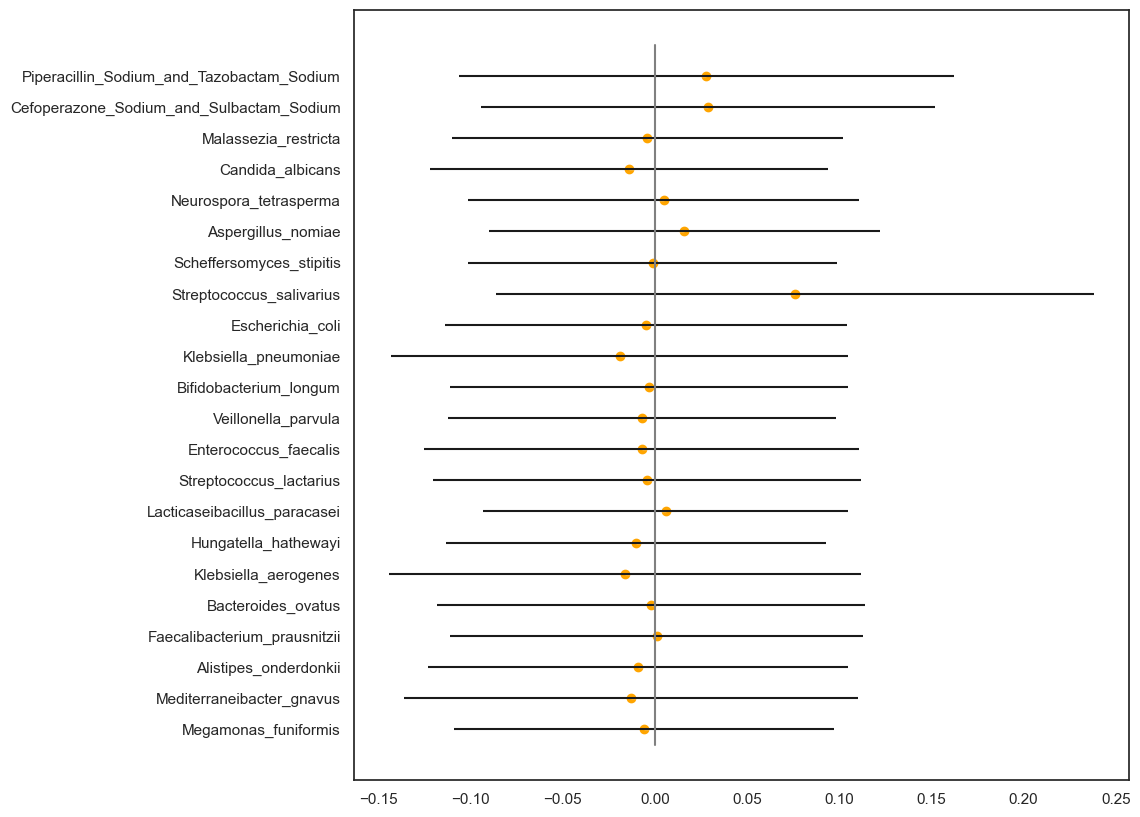

(194, 3)


The version of PyMC you are using is very outdated.

Please upgrade to the latest version of PyMC https://www.pymc.io/projects/docs/en/stable/installation.html

Also notice that PyMC3 has been renamed to PyMC.
D:\environment\envs\pymc3\lib\site-packages\deprecat\classic.py:232: FutureWarning: In v4.0, pm.sample will return an `arviz.InferenceData` object instead of a `MultiTrace` by default. You can pass return_inferencedata=True or return_inferencedata=False to be safe and silence this warning.
  return wrapped_(*args_, **kwargs_)
Sequential sampling (2 chains in 1 job)
CompoundStep
>BinaryGibbsMetropolis: [xi_taxa, xi_drugs]
>NUTS: [intercp, my_sigma, beta_drugs, tau_drugs, beta_taxa, tau_taxa]


Sampling 2 chains for 2_500 tune and 10_000 draw iterations (5_000 + 20_000 draws total) took 1330 seconds.
There were 145 divergences after tuning. Increase `target_accept` or reparameterize.
There were 724 divergences after tuning. Increase `target_accept` or reparameterize.
The acceptance probability does not match the target. It is 0.5336192933210331, but should be close to 0.8. Try to increase the number of tuning steps.
The estimated number of effective samples is smaller than 200 for some parameters.
Got error No model on context stack. trying to find log_likelihood in translation.
D:\environment\envs\pymc3\lib\site-packages\arviz\data\io_pymc3_3x.py:98: FutureWarning: Using `from_pymc3` without the model will be deprecated in a future release. Not using the model will return less accurate and less useful results. Make sure you use the model argument or call from_pymc3 within a model context.
  warnings.warn(


Mediterraneibacter_gnavus


<Figure size 640x480 with 0 Axes>

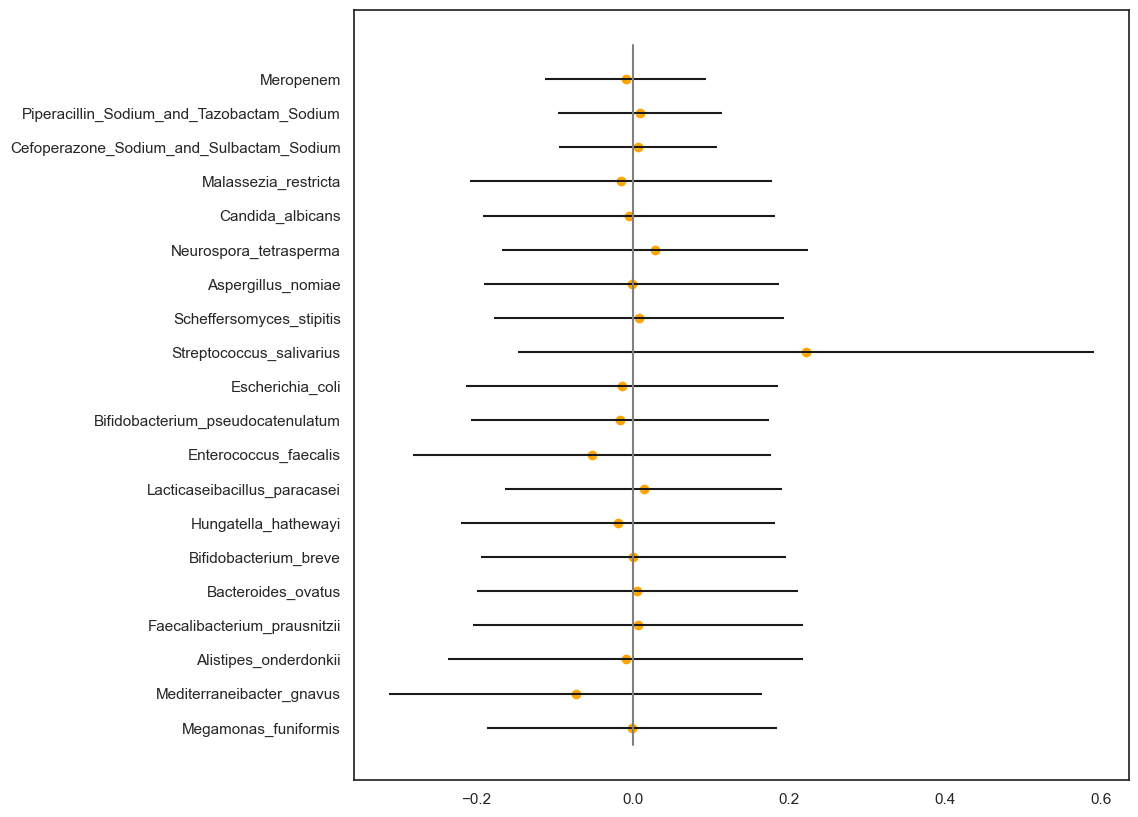

(93, 3)


The version of PyMC you are using is very outdated.

Please upgrade to the latest version of PyMC https://www.pymc.io/projects/docs/en/stable/installation.html

Also notice that PyMC3 has been renamed to PyMC.
D:\environment\envs\pymc3\lib\site-packages\deprecat\classic.py:232: FutureWarning: In v4.0, pm.sample will return an `arviz.InferenceData` object instead of a `MultiTrace` by default. You can pass return_inferencedata=True or return_inferencedata=False to be safe and silence this warning.
  return wrapped_(*args_, **kwargs_)
Sequential sampling (2 chains in 1 job)
CompoundStep
>BinaryGibbsMetropolis: [xi_taxa, xi_drugs]
>NUTS: [intercp, my_sigma, beta_drugs, tau_drugs, beta_taxa, tau_taxa]


Sampling 2 chains for 2_500 tune and 10_000 draw iterations (5_000 + 20_000 draws total) took 1272 seconds.
There were 37 divergences after tuning. Increase `target_accept` or reparameterize.
There were 154 divergences after tuning. Increase `target_accept` or reparameterize.
The number of effective samples is smaller than 10% for some parameters.
Got error No model on context stack. trying to find log_likelihood in translation.
D:\environment\envs\pymc3\lib\site-packages\arviz\data\io_pymc3_3x.py:98: FutureWarning: Using `from_pymc3` without the model will be deprecated in a future release. Not using the model will return less accurate and less useful results. Make sure you use the model argument or call from_pymc3 within a model context.
  warnings.warn(


Alistipes_onderdonkii


<Figure size 640x480 with 0 Axes>

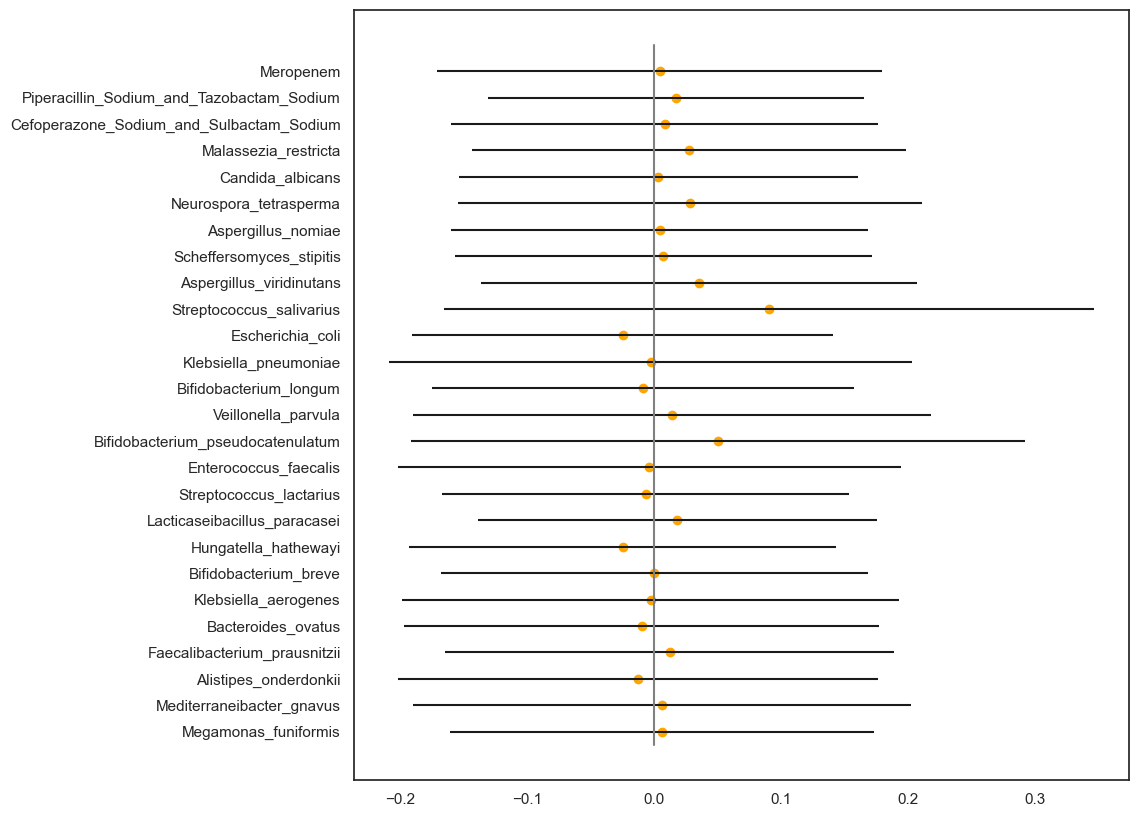

(213, 2)


The version of PyMC you are using is very outdated.

Please upgrade to the latest version of PyMC https://www.pymc.io/projects/docs/en/stable/installation.html

Also notice that PyMC3 has been renamed to PyMC.
D:\environment\envs\pymc3\lib\site-packages\deprecat\classic.py:232: FutureWarning: In v4.0, pm.sample will return an `arviz.InferenceData` object instead of a `MultiTrace` by default. You can pass return_inferencedata=True or return_inferencedata=False to be safe and silence this warning.
  return wrapped_(*args_, **kwargs_)
Sequential sampling (2 chains in 1 job)
CompoundStep
>BinaryGibbsMetropolis: [xi_taxa, xi_drugs]
>NUTS: [intercp, my_sigma, beta_drugs, tau_drugs, beta_taxa, tau_taxa]


Sampling 2 chains for 2_500 tune and 10_000 draw iterations (5_000 + 20_000 draws total) took 999 seconds.
There were 173 divergences after tuning. Increase `target_accept` or reparameterize.
The acceptance probability does not match the target. It is 0.7208430918268356, but should be close to 0.8. Try to increase the number of tuning steps.
There were 336 divergences after tuning. Increase `target_accept` or reparameterize.
The number of effective samples is smaller than 10% for some parameters.
Got error No model on context stack. trying to find log_likelihood in translation.
D:\environment\envs\pymc3\lib\site-packages\arviz\data\io_pymc3_3x.py:98: FutureWarning: Using `from_pymc3` without the model will be deprecated in a future release. Not using the model will return less accurate and less useful results. Make sure you use the model argument or call from_pymc3 within a model context.
  warnings.warn(


Faecalibacterium_prausnitzii


<Figure size 640x480 with 0 Axes>

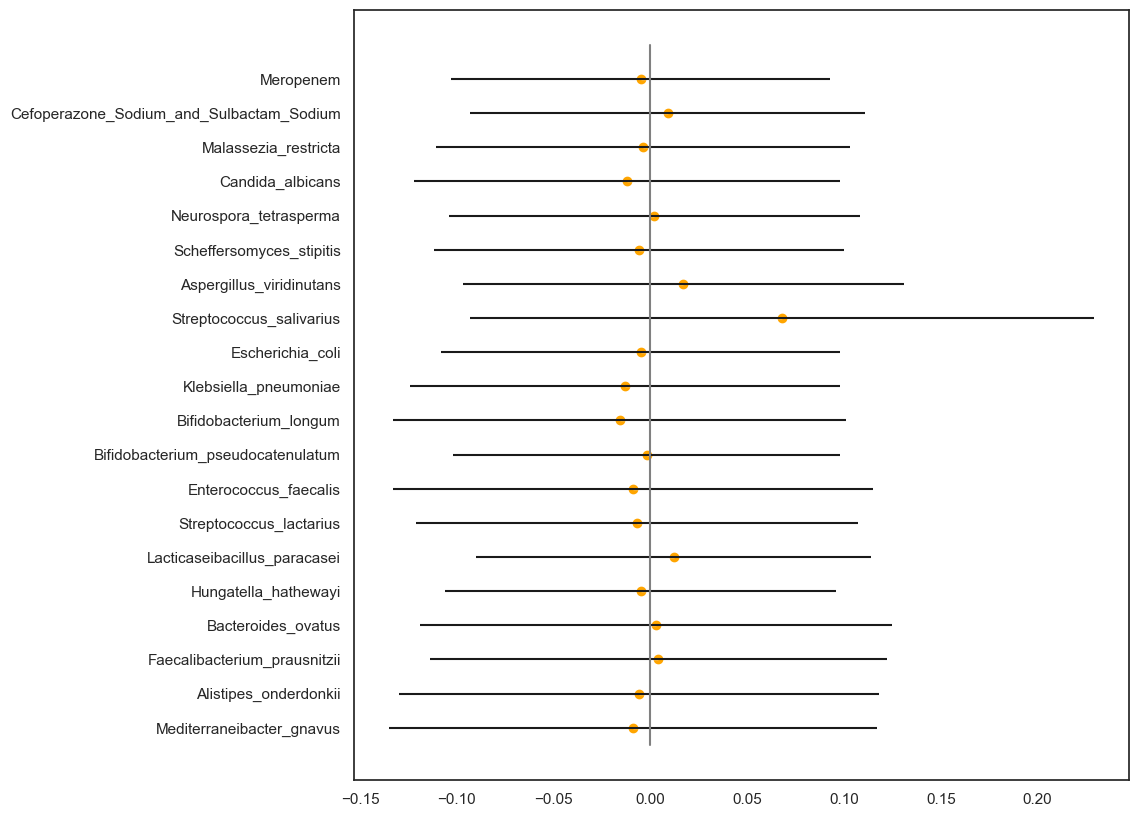

(209, 3)


The version of PyMC you are using is very outdated.

Please upgrade to the latest version of PyMC https://www.pymc.io/projects/docs/en/stable/installation.html

Also notice that PyMC3 has been renamed to PyMC.
D:\environment\envs\pymc3\lib\site-packages\deprecat\classic.py:232: FutureWarning: In v4.0, pm.sample will return an `arviz.InferenceData` object instead of a `MultiTrace` by default. You can pass return_inferencedata=True or return_inferencedata=False to be safe and silence this warning.
  return wrapped_(*args_, **kwargs_)
Sequential sampling (2 chains in 1 job)
CompoundStep
>BinaryGibbsMetropolis: [xi_taxa, xi_drugs]
>NUTS: [intercp, my_sigma, beta_drugs, tau_drugs, beta_taxa, tau_taxa]


Sampling 2 chains for 2_500 tune and 10_000 draw iterations (5_000 + 20_000 draws total) took 1153 seconds.
There were 99 divergences after tuning. Increase `target_accept` or reparameterize.
There were 550 divergences after tuning. Increase `target_accept` or reparameterize.
The acceptance probability does not match the target. It is 0.4175362374749327, but should be close to 0.8. Try to increase the number of tuning steps.
The rhat statistic is larger than 1.05 for some parameters. This indicates slight problems during sampling.
The estimated number of effective samples is smaller than 200 for some parameters.
Got error No model on context stack. trying to find log_likelihood in translation.
D:\environment\envs\pymc3\lib\site-packages\arviz\data\io_pymc3_3x.py:98: FutureWarning: Using `from_pymc3` without the model will be deprecated in a future release. Not using the model will return less accurate and less useful results. Make sure you use the model argument or call from_pymc3 with

Bacteroides_ovatus


<Figure size 640x480 with 0 Axes>

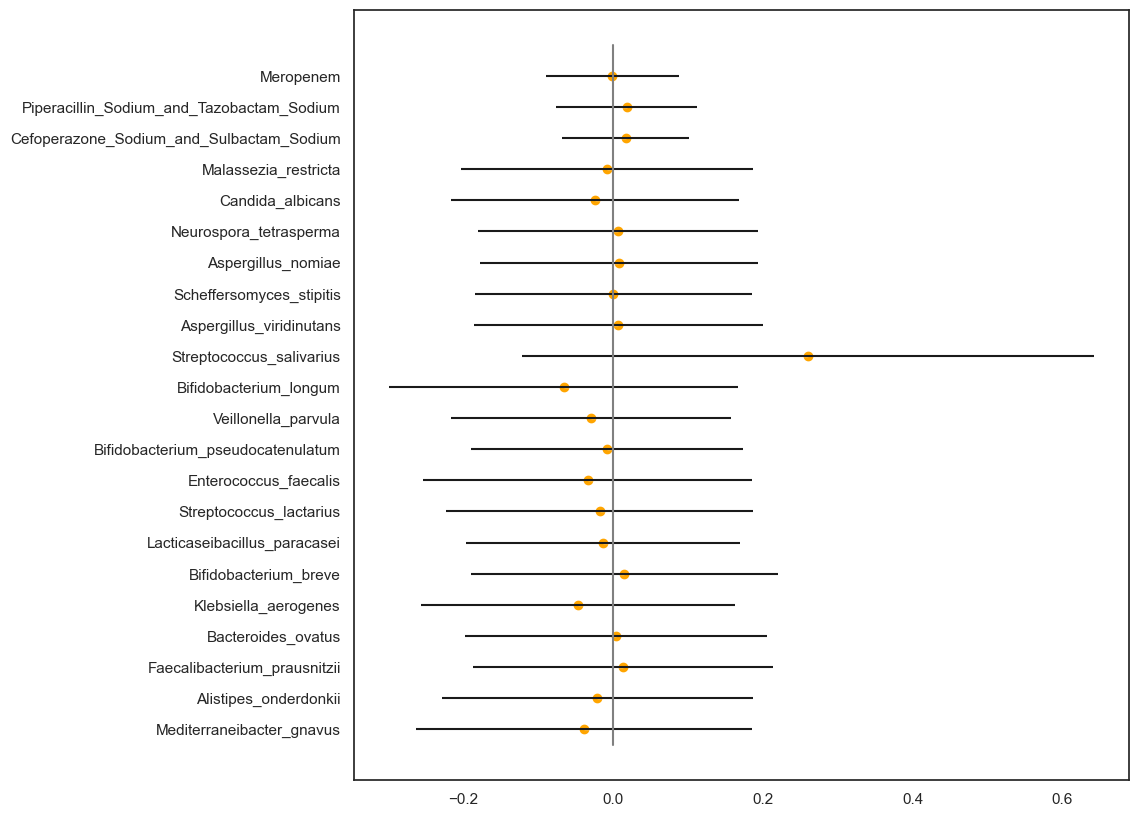

(213, 2)


The version of PyMC you are using is very outdated.

Please upgrade to the latest version of PyMC https://www.pymc.io/projects/docs/en/stable/installation.html

Also notice that PyMC3 has been renamed to PyMC.
D:\environment\envs\pymc3\lib\site-packages\deprecat\classic.py:232: FutureWarning: In v4.0, pm.sample will return an `arviz.InferenceData` object instead of a `MultiTrace` by default. You can pass return_inferencedata=True or return_inferencedata=False to be safe and silence this warning.
  return wrapped_(*args_, **kwargs_)
Sequential sampling (2 chains in 1 job)
CompoundStep
>BinaryGibbsMetropolis: [xi_taxa, xi_drugs]
>NUTS: [intercp, my_sigma, beta_drugs, tau_drugs, beta_taxa, tau_taxa]


Sampling 2 chains for 2_500 tune and 10_000 draw iterations (5_000 + 20_000 draws total) took 832 seconds.
D:\environment\envs\pymc3\lib\site-packages\arviz\stats\diagnostics.py:586: RuntimeWarning: invalid value encountered in double_scalars
  (between_chain_variance / within_chain_variance + num_samples - 1) / (num_samples)
There were 104 divergences after tuning. Increase `target_accept` or reparameterize.
There were 275 divergences after tuning. Increase `target_accept` or reparameterize.
The acceptance probability does not match the target. It is 0.6589273241537018, but should be close to 0.8. Try to increase the number of tuning steps.
The number of effective samples is smaller than 10% for some parameters.
Got error No model on context stack. trying to find log_likelihood in translation.
D:\environment\envs\pymc3\lib\site-packages\arviz\data\io_pymc3_3x.py:98: FutureWarning: Using `from_pymc3` without the model will be deprecated in a future release. Not using the model will ret

Klebsiella_aerogenes


<Figure size 640x480 with 0 Axes>

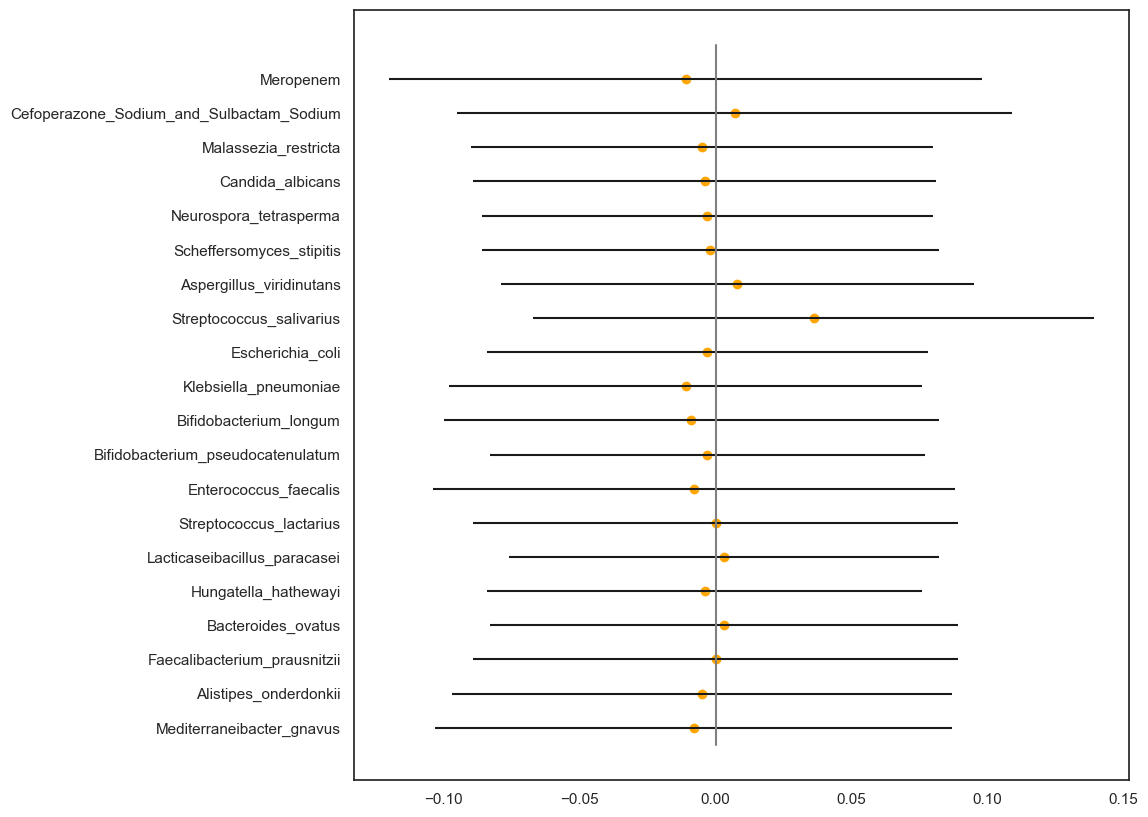

(213, 2)


The version of PyMC you are using is very outdated.

Please upgrade to the latest version of PyMC https://www.pymc.io/projects/docs/en/stable/installation.html

Also notice that PyMC3 has been renamed to PyMC.
D:\environment\envs\pymc3\lib\site-packages\deprecat\classic.py:232: FutureWarning: In v4.0, pm.sample will return an `arviz.InferenceData` object instead of a `MultiTrace` by default. You can pass return_inferencedata=True or return_inferencedata=False to be safe and silence this warning.
  return wrapped_(*args_, **kwargs_)
Sequential sampling (2 chains in 1 job)
CompoundStep
>BinaryGibbsMetropolis: [xi_taxa, xi_drugs]
>NUTS: [intercp, my_sigma, beta_drugs, tau_drugs, beta_taxa, tau_taxa]


Sampling 2 chains for 2_500 tune and 10_000 draw iterations (5_000 + 20_000 draws total) took 879 seconds.
There were 225 divergences after tuning. Increase `target_accept` or reparameterize.
The acceptance probability does not match the target. It is 0.6454023937181298, but should be close to 0.8. Try to increase the number of tuning steps.
There were 327 divergences after tuning. Increase `target_accept` or reparameterize.
The acceptance probability does not match the target. It is 0.6367329243159944, but should be close to 0.8. Try to increase the number of tuning steps.
The estimated number of effective samples is smaller than 200 for some parameters.
Got error No model on context stack. trying to find log_likelihood in translation.
D:\environment\envs\pymc3\lib\site-packages\arviz\data\io_pymc3_3x.py:98: FutureWarning: Using `from_pymc3` without the model will be deprecated in a future release. Not using the model will return less accurate and less useful results. Make sure you us

Bifidobacterium_breve


<Figure size 640x480 with 0 Axes>

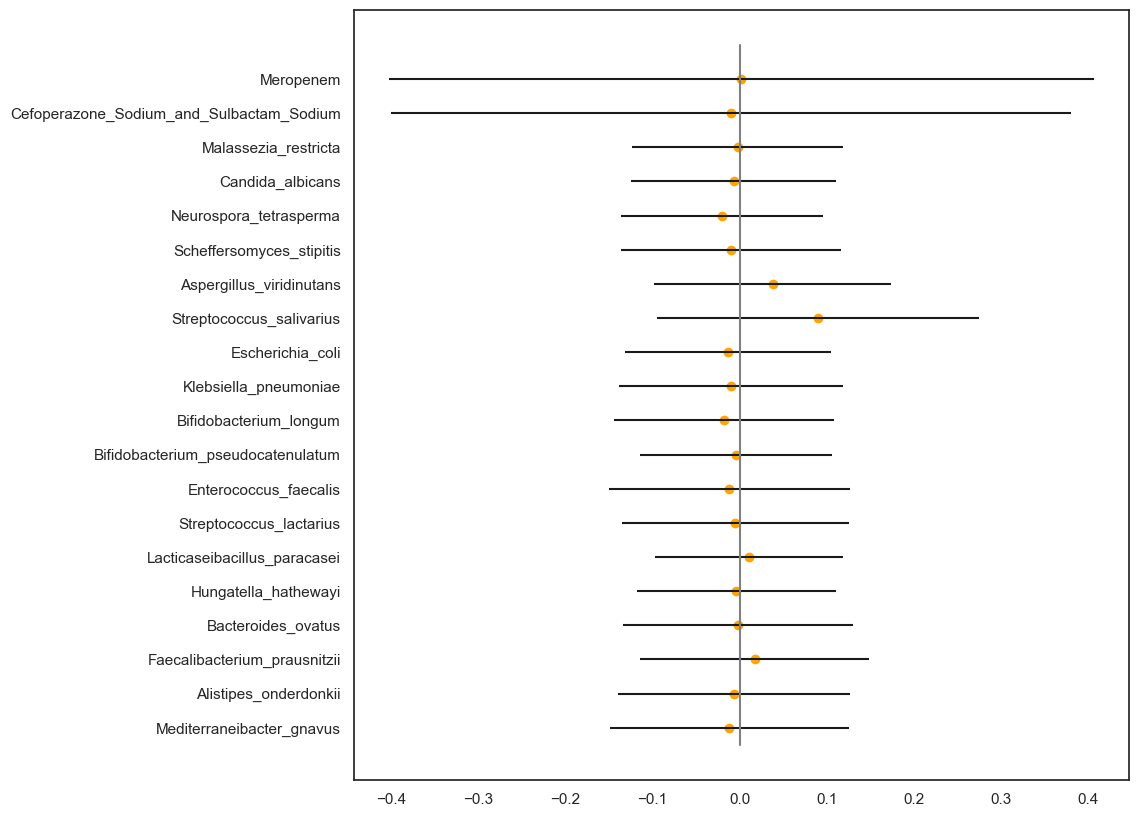

(196, 3)


The version of PyMC you are using is very outdated.

Please upgrade to the latest version of PyMC https://www.pymc.io/projects/docs/en/stable/installation.html

Also notice that PyMC3 has been renamed to PyMC.
D:\environment\envs\pymc3\lib\site-packages\deprecat\classic.py:232: FutureWarning: In v4.0, pm.sample will return an `arviz.InferenceData` object instead of a `MultiTrace` by default. You can pass return_inferencedata=True or return_inferencedata=False to be safe and silence this warning.
  return wrapped_(*args_, **kwargs_)
Sequential sampling (2 chains in 1 job)
CompoundStep
>BinaryGibbsMetropolis: [xi_taxa, xi_drugs]
>NUTS: [intercp, my_sigma, beta_drugs, tau_drugs, beta_taxa, tau_taxa]


Sampling 2 chains for 2_500 tune and 10_000 draw iterations (5_000 + 20_000 draws total) took 1349 seconds.
There were 125 divergences after tuning. Increase `target_accept` or reparameterize.
There were 329 divergences after tuning. Increase `target_accept` or reparameterize.
The acceptance probability does not match the target. It is 0.6109928633690301, but should be close to 0.8. Try to increase the number of tuning steps.
The number of effective samples is smaller than 10% for some parameters.
Got error No model on context stack. trying to find log_likelihood in translation.
D:\environment\envs\pymc3\lib\site-packages\arviz\data\io_pymc3_3x.py:98: FutureWarning: Using `from_pymc3` without the model will be deprecated in a future release. Not using the model will return less accurate and less useful results. Make sure you use the model argument or call from_pymc3 within a model context.
  warnings.warn(


Hungatella_hathewayi


<Figure size 640x480 with 0 Axes>

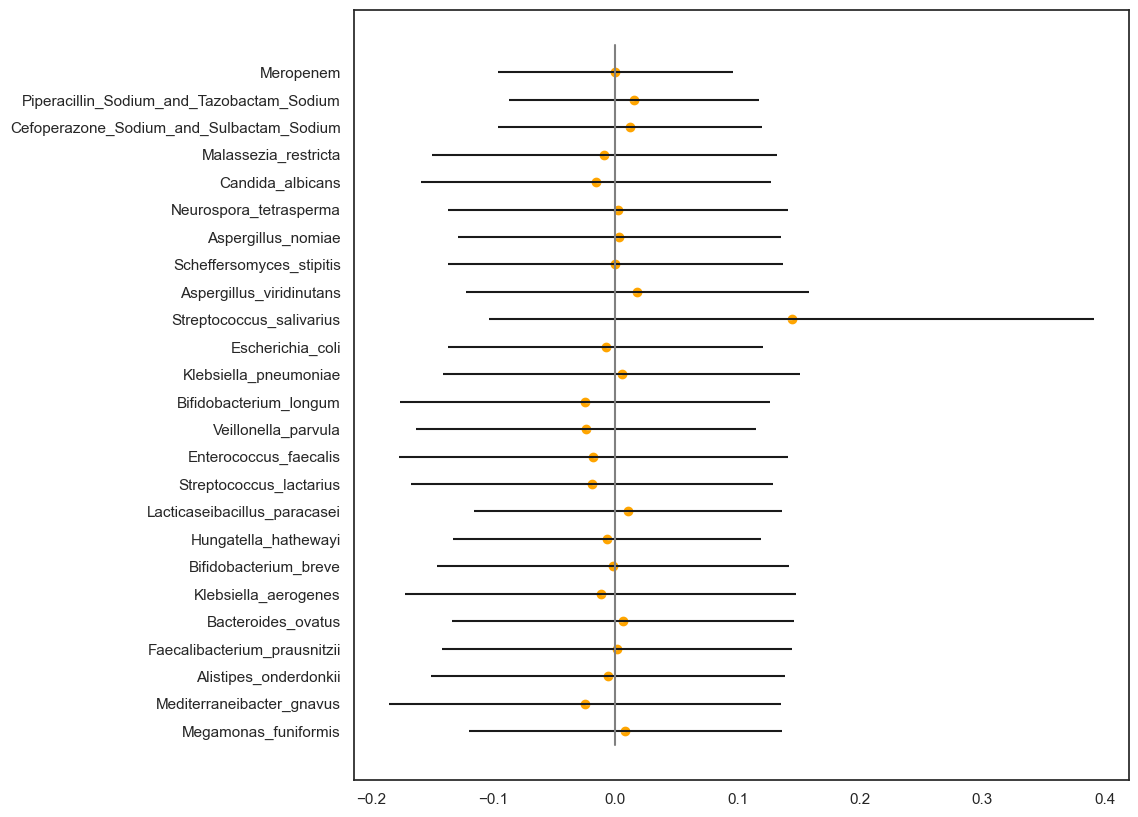

(178, 3)


The version of PyMC you are using is very outdated.

Please upgrade to the latest version of PyMC https://www.pymc.io/projects/docs/en/stable/installation.html

Also notice that PyMC3 has been renamed to PyMC.
D:\environment\envs\pymc3\lib\site-packages\deprecat\classic.py:232: FutureWarning: In v4.0, pm.sample will return an `arviz.InferenceData` object instead of a `MultiTrace` by default. You can pass return_inferencedata=True or return_inferencedata=False to be safe and silence this warning.
  return wrapped_(*args_, **kwargs_)
Sequential sampling (2 chains in 1 job)
CompoundStep
>BinaryGibbsMetropolis: [xi_taxa, xi_drugs]
>NUTS: [intercp, my_sigma, beta_drugs, tau_drugs, beta_taxa, tau_taxa]


Sampling 2 chains for 2_500 tune and 10_000 draw iterations (5_000 + 20_000 draws total) took 1318 seconds.
There were 40 divergences after tuning. Increase `target_accept` or reparameterize.
There were 173 divergences after tuning. Increase `target_accept` or reparameterize.
The acceptance probability does not match the target. It is 0.6212585959918157, but should be close to 0.8. Try to increase the number of tuning steps.
The number of effective samples is smaller than 10% for some parameters.
Got error No model on context stack. trying to find log_likelihood in translation.
D:\environment\envs\pymc3\lib\site-packages\arviz\data\io_pymc3_3x.py:98: FutureWarning: Using `from_pymc3` without the model will be deprecated in a future release. Not using the model will return less accurate and less useful results. Make sure you use the model argument or call from_pymc3 within a model context.
  warnings.warn(


Lacticaseibacillus_paracasei


<Figure size 640x480 with 0 Axes>

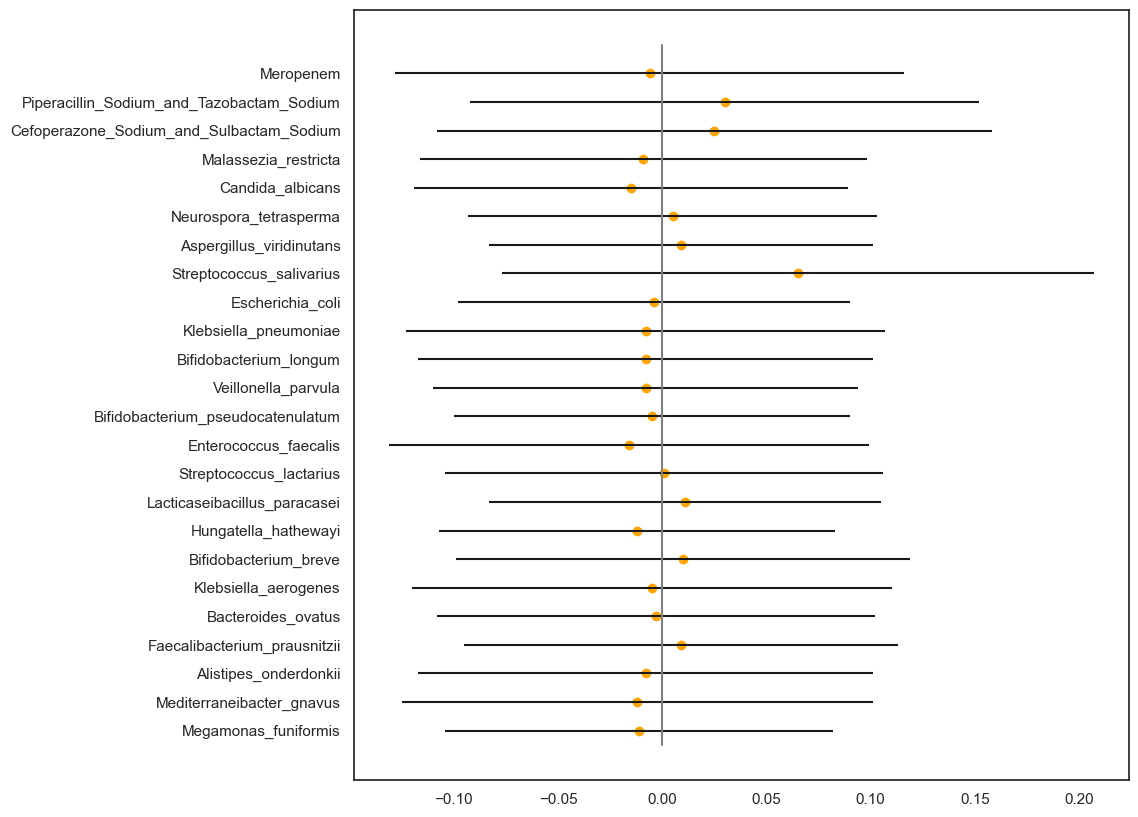

(213, 2)


The version of PyMC you are using is very outdated.

Please upgrade to the latest version of PyMC https://www.pymc.io/projects/docs/en/stable/installation.html

Also notice that PyMC3 has been renamed to PyMC.
D:\environment\envs\pymc3\lib\site-packages\deprecat\classic.py:232: FutureWarning: In v4.0, pm.sample will return an `arviz.InferenceData` object instead of a `MultiTrace` by default. You can pass return_inferencedata=True or return_inferencedata=False to be safe and silence this warning.
  return wrapped_(*args_, **kwargs_)
Sequential sampling (2 chains in 1 job)
CompoundStep
>BinaryGibbsMetropolis: [xi_taxa, xi_drugs]
>NUTS: [intercp, my_sigma, beta_drugs, tau_drugs, beta_taxa, tau_taxa]


Sampling 2 chains for 2_500 tune and 10_000 draw iterations (5_000 + 20_000 draws total) took 1080 seconds.
There were 308 divergences after tuning. Increase `target_accept` or reparameterize.
The acceptance probability does not match the target. It is 0.6439342705035267, but should be close to 0.8. Try to increase the number of tuning steps.
There were 437 divergences after tuning. Increase `target_accept` or reparameterize.
The rhat statistic is larger than 1.05 for some parameters. This indicates slight problems during sampling.
The estimated number of effective samples is smaller than 200 for some parameters.
Got error No model on context stack. trying to find log_likelihood in translation.
D:\environment\envs\pymc3\lib\site-packages\arviz\data\io_pymc3_3x.py:98: FutureWarning: Using `from_pymc3` without the model will be deprecated in a future release. Not using the model will return less accurate and less useful results. Make sure you use the model argument or call from_pymc3 wit

Streptococcus_lactarius


<Figure size 640x480 with 0 Axes>

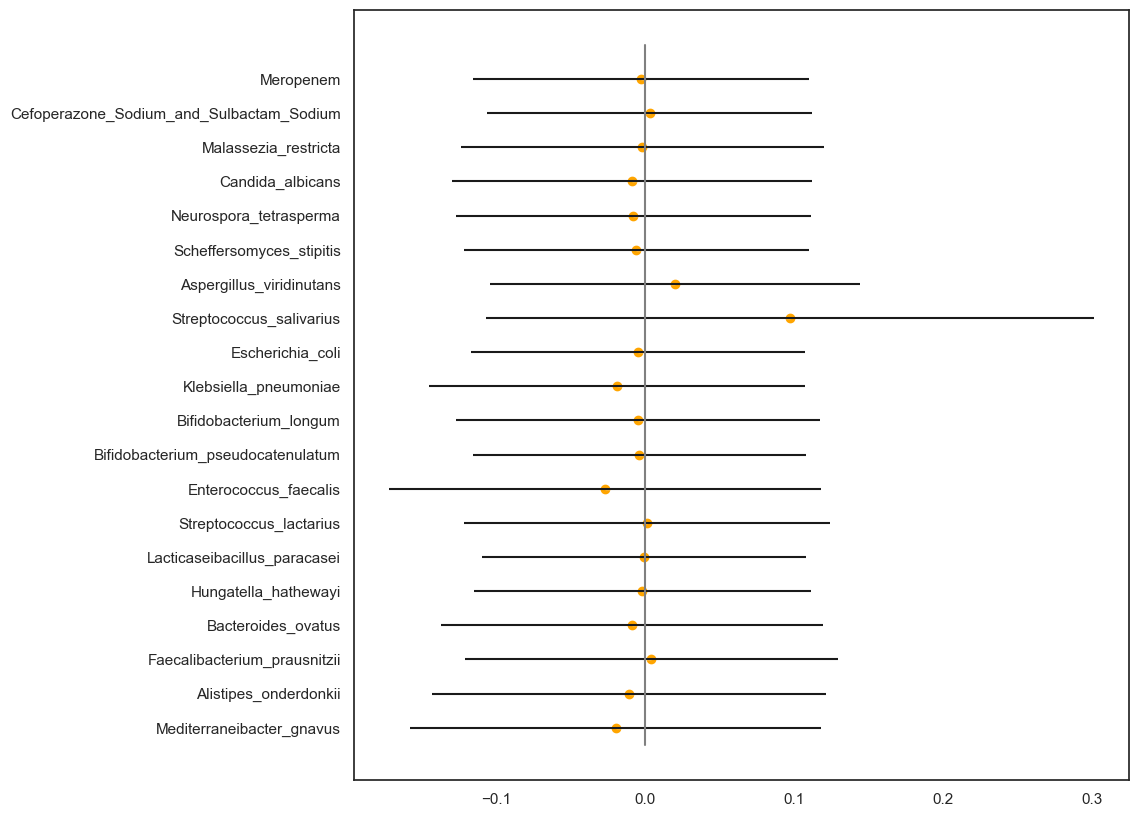

(213, 2)


The version of PyMC you are using is very outdated.

Please upgrade to the latest version of PyMC https://www.pymc.io/projects/docs/en/stable/installation.html

Also notice that PyMC3 has been renamed to PyMC.
D:\environment\envs\pymc3\lib\site-packages\deprecat\classic.py:232: FutureWarning: In v4.0, pm.sample will return an `arviz.InferenceData` object instead of a `MultiTrace` by default. You can pass return_inferencedata=True or return_inferencedata=False to be safe and silence this warning.
  return wrapped_(*args_, **kwargs_)
Sequential sampling (2 chains in 1 job)
CompoundStep
>BinaryGibbsMetropolis: [xi_taxa, xi_drugs]
>NUTS: [intercp, my_sigma, beta_drugs, tau_drugs, beta_taxa, tau_taxa]


Sampling 2 chains for 2_500 tune and 10_000 draw iterations (5_000 + 20_000 draws total) took 1064 seconds.
There were 474 divergences after tuning. Increase `target_accept` or reparameterize.
The acceptance probability does not match the target. It is 0.6252188303125431, but should be close to 0.8. Try to increase the number of tuning steps.
There were 578 divergences after tuning. Increase `target_accept` or reparameterize.
The number of effective samples is smaller than 10% for some parameters.
Got error No model on context stack. trying to find log_likelihood in translation.
D:\environment\envs\pymc3\lib\site-packages\arviz\data\io_pymc3_3x.py:98: FutureWarning: Using `from_pymc3` without the model will be deprecated in a future release. Not using the model will return less accurate and less useful results. Make sure you use the model argument or call from_pymc3 within a model context.
  warnings.warn(


Enterococcus_faecalis


<Figure size 640x480 with 0 Axes>

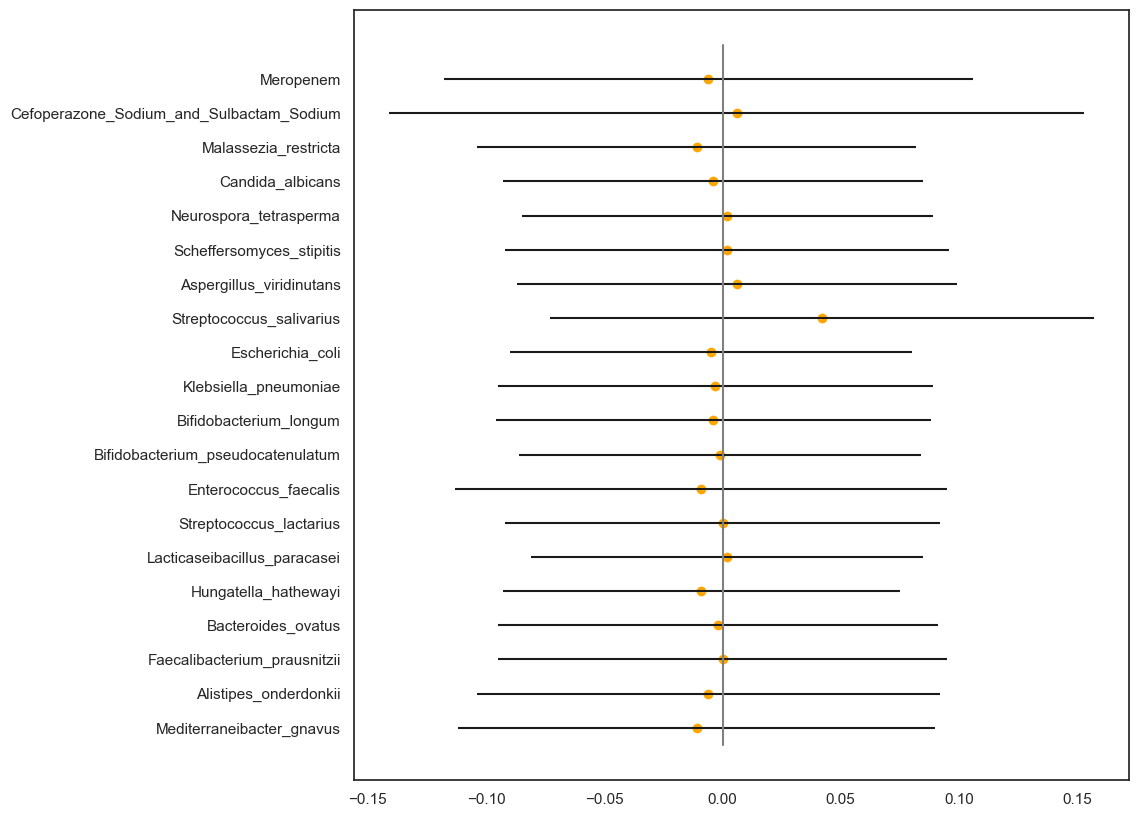

(211, 3)


The version of PyMC you are using is very outdated.

Please upgrade to the latest version of PyMC https://www.pymc.io/projects/docs/en/stable/installation.html

Also notice that PyMC3 has been renamed to PyMC.
D:\environment\envs\pymc3\lib\site-packages\deprecat\classic.py:232: FutureWarning: In v4.0, pm.sample will return an `arviz.InferenceData` object instead of a `MultiTrace` by default. You can pass return_inferencedata=True or return_inferencedata=False to be safe and silence this warning.
  return wrapped_(*args_, **kwargs_)
Sequential sampling (2 chains in 1 job)
CompoundStep
>BinaryGibbsMetropolis: [xi_taxa, xi_drugs]
>NUTS: [intercp, my_sigma, beta_drugs, tau_drugs, beta_taxa, tau_taxa]


Sampling 2 chains for 2_500 tune and 10_000 draw iterations (5_000 + 20_000 draws total) took 1766 seconds.
There were 301 divergences after tuning. Increase `target_accept` or reparameterize.
There were 383 divergences after tuning. Increase `target_accept` or reparameterize.
The number of effective samples is smaller than 10% for some parameters.
Got error No model on context stack. trying to find log_likelihood in translation.
D:\environment\envs\pymc3\lib\site-packages\arviz\data\io_pymc3_3x.py:98: FutureWarning: Using `from_pymc3` without the model will be deprecated in a future release. Not using the model will return less accurate and less useful results. Make sure you use the model argument or call from_pymc3 within a model context.
  warnings.warn(


Bifidobacterium_pseudocatenulatum


<Figure size 640x480 with 0 Axes>

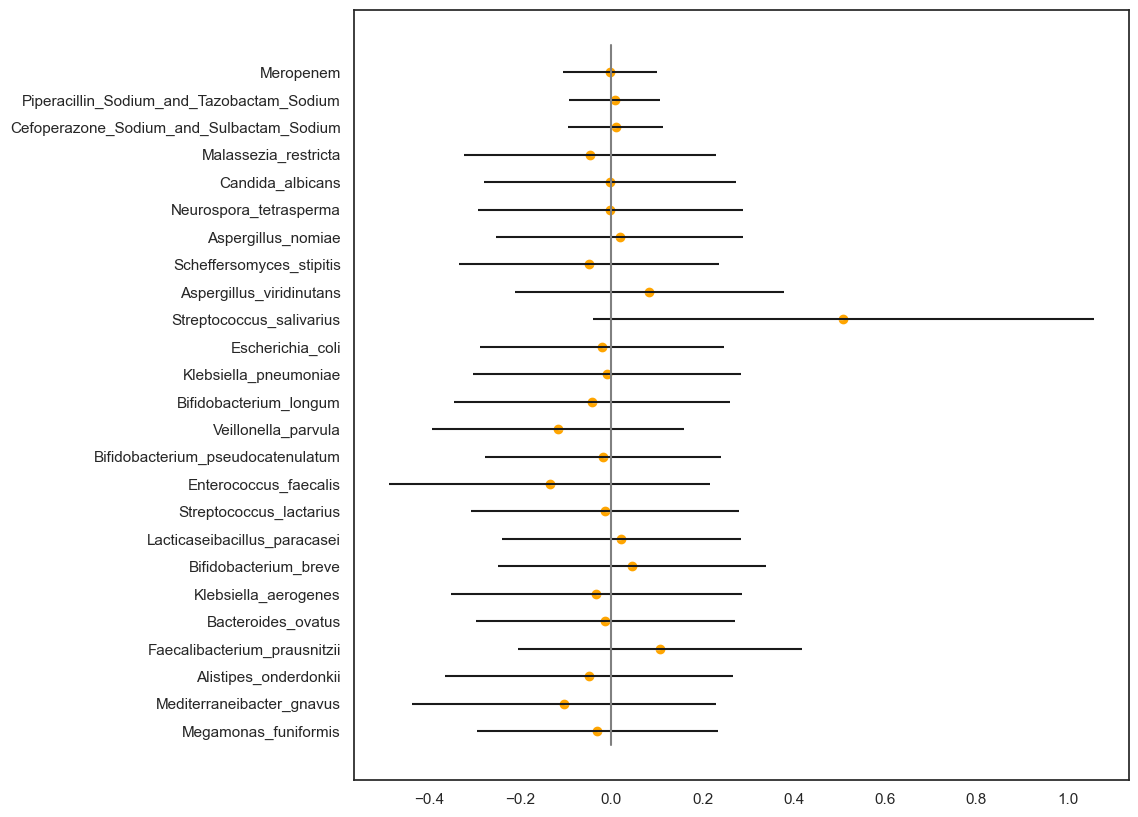

(213, 2)


The version of PyMC you are using is very outdated.

Please upgrade to the latest version of PyMC https://www.pymc.io/projects/docs/en/stable/installation.html

Also notice that PyMC3 has been renamed to PyMC.
D:\environment\envs\pymc3\lib\site-packages\deprecat\classic.py:232: FutureWarning: In v4.0, pm.sample will return an `arviz.InferenceData` object instead of a `MultiTrace` by default. You can pass return_inferencedata=True or return_inferencedata=False to be safe and silence this warning.
  return wrapped_(*args_, **kwargs_)
Sequential sampling (2 chains in 1 job)
CompoundStep
>BinaryGibbsMetropolis: [xi_taxa, xi_drugs]
>NUTS: [intercp, my_sigma, beta_drugs, tau_drugs, beta_taxa, tau_taxa]


Sampling 2 chains for 2_500 tune and 10_000 draw iterations (5_000 + 20_000 draws total) took 941 seconds.
There were 290 divergences after tuning. Increase `target_accept` or reparameterize.
The acceptance probability does not match the target. It is 0.5521625678202013, but should be close to 0.8. Try to increase the number of tuning steps.
There were 389 divergences after tuning. Increase `target_accept` or reparameterize.
The estimated number of effective samples is smaller than 200 for some parameters.
Got error No model on context stack. trying to find log_likelihood in translation.
D:\environment\envs\pymc3\lib\site-packages\arviz\data\io_pymc3_3x.py:98: FutureWarning: Using `from_pymc3` without the model will be deprecated in a future release. Not using the model will return less accurate and less useful results. Make sure you use the model argument or call from_pymc3 within a model context.
  warnings.warn(


Veillonella_parvula


<Figure size 640x480 with 0 Axes>

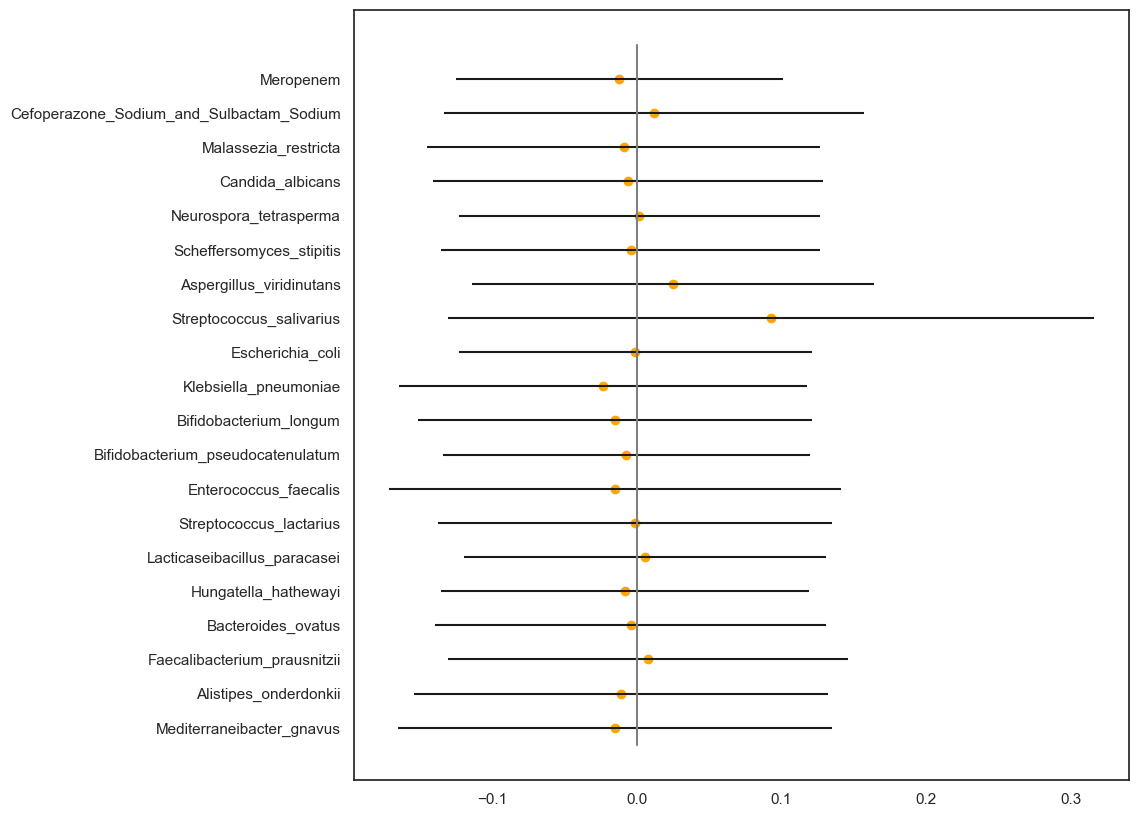

(213, 2)


The version of PyMC you are using is very outdated.

Please upgrade to the latest version of PyMC https://www.pymc.io/projects/docs/en/stable/installation.html

Also notice that PyMC3 has been renamed to PyMC.
D:\environment\envs\pymc3\lib\site-packages\deprecat\classic.py:232: FutureWarning: In v4.0, pm.sample will return an `arviz.InferenceData` object instead of a `MultiTrace` by default. You can pass return_inferencedata=True or return_inferencedata=False to be safe and silence this warning.
  return wrapped_(*args_, **kwargs_)
Sequential sampling (2 chains in 1 job)
CompoundStep
>BinaryGibbsMetropolis: [xi_taxa, xi_drugs]
>NUTS: [intercp, my_sigma, beta_drugs, tau_drugs, beta_taxa, tau_taxa]


Sampling 2 chains for 2_500 tune and 10_000 draw iterations (5_000 + 20_000 draws total) took 1022 seconds.
There were 151 divergences after tuning. Increase `target_accept` or reparameterize.
There were 386 divergences after tuning. Increase `target_accept` or reparameterize.
The acceptance probability does not match the target. It is 0.5887161385231804, but should be close to 0.8. Try to increase the number of tuning steps.
The number of effective samples is smaller than 10% for some parameters.
Got error No model on context stack. trying to find log_likelihood in translation.
D:\environment\envs\pymc3\lib\site-packages\arviz\data\io_pymc3_3x.py:98: FutureWarning: Using `from_pymc3` without the model will be deprecated in a future release. Not using the model will return less accurate and less useful results. Make sure you use the model argument or call from_pymc3 within a model context.
  warnings.warn(


Bifidobacterium_longum


<Figure size 640x480 with 0 Axes>

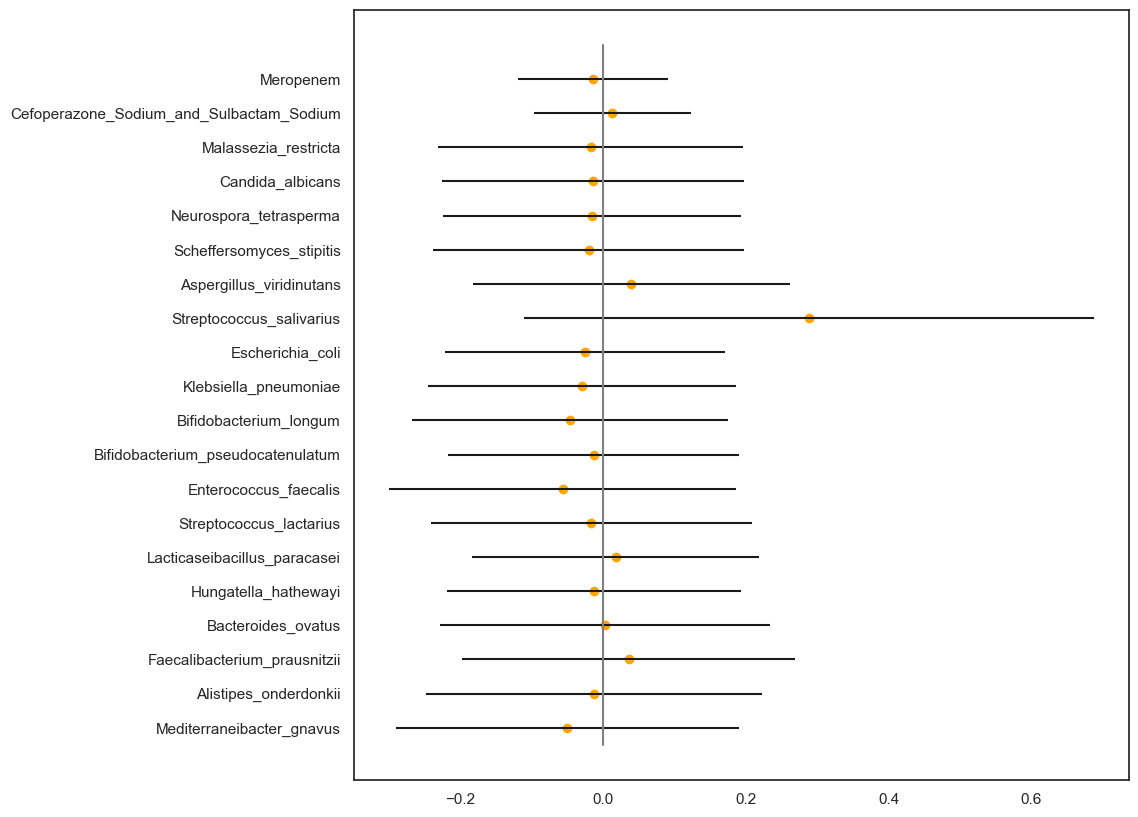

(213, 2)


The version of PyMC you are using is very outdated.

Please upgrade to the latest version of PyMC https://www.pymc.io/projects/docs/en/stable/installation.html

Also notice that PyMC3 has been renamed to PyMC.
D:\environment\envs\pymc3\lib\site-packages\deprecat\classic.py:232: FutureWarning: In v4.0, pm.sample will return an `arviz.InferenceData` object instead of a `MultiTrace` by default. You can pass return_inferencedata=True or return_inferencedata=False to be safe and silence this warning.
  return wrapped_(*args_, **kwargs_)
Sequential sampling (2 chains in 1 job)
CompoundStep
>BinaryGibbsMetropolis: [xi_taxa, xi_drugs]
>NUTS: [intercp, my_sigma, beta_drugs, tau_drugs, beta_taxa, tau_taxa]


Sampling 2 chains for 2_500 tune and 10_000 draw iterations (5_000 + 20_000 draws total) took 968 seconds.
There were 577 divergences after tuning. Increase `target_accept` or reparameterize.
There were 702 divergences after tuning. Increase `target_accept` or reparameterize.
The acceptance probability does not match the target. It is 0.719715535985119, but should be close to 0.8. Try to increase the number of tuning steps.
The number of effective samples is smaller than 10% for some parameters.
Got error No model on context stack. trying to find log_likelihood in translation.
D:\environment\envs\pymc3\lib\site-packages\arviz\data\io_pymc3_3x.py:98: FutureWarning: Using `from_pymc3` without the model will be deprecated in a future release. Not using the model will return less accurate and less useful results. Make sure you use the model argument or call from_pymc3 within a model context.
  warnings.warn(


Klebsiella_pneumoniae


<Figure size 640x480 with 0 Axes>

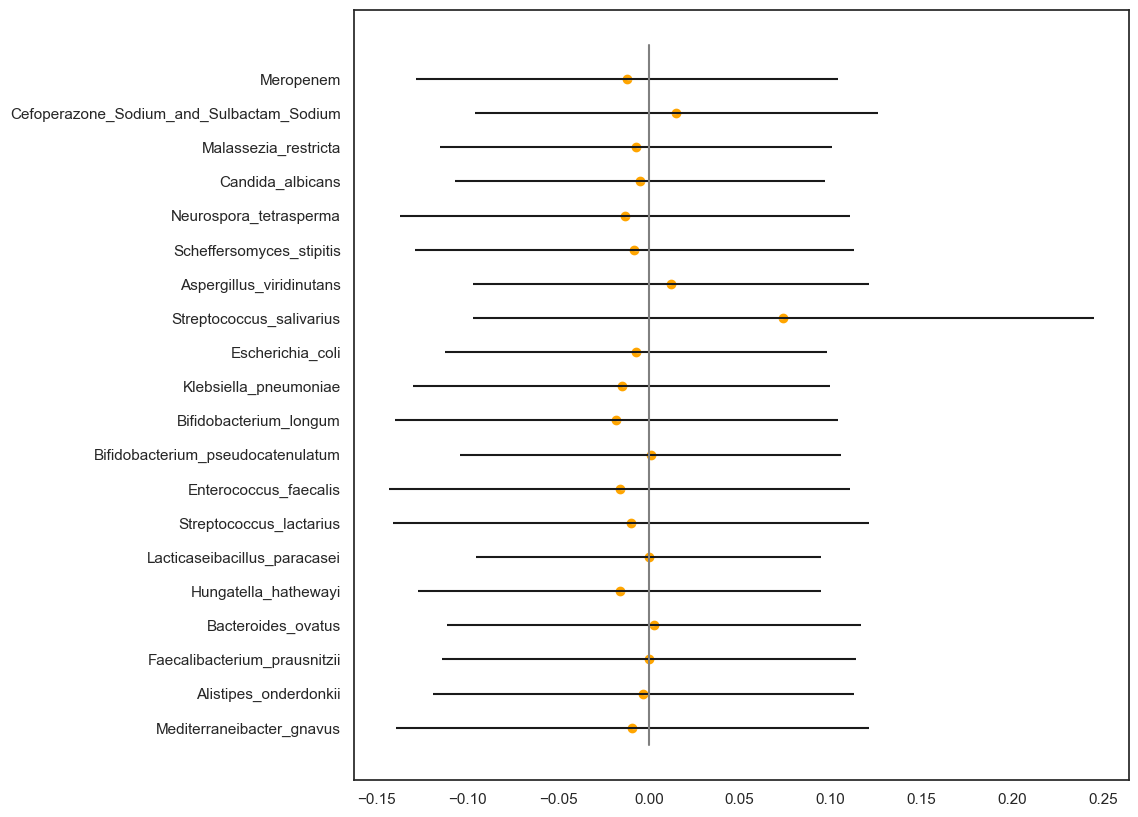

(213, 2)


The version of PyMC you are using is very outdated.

Please upgrade to the latest version of PyMC https://www.pymc.io/projects/docs/en/stable/installation.html

Also notice that PyMC3 has been renamed to PyMC.
D:\environment\envs\pymc3\lib\site-packages\deprecat\classic.py:232: FutureWarning: In v4.0, pm.sample will return an `arviz.InferenceData` object instead of a `MultiTrace` by default. You can pass return_inferencedata=True or return_inferencedata=False to be safe and silence this warning.
  return wrapped_(*args_, **kwargs_)
Sequential sampling (2 chains in 1 job)
CompoundStep
>BinaryGibbsMetropolis: [xi_taxa, xi_drugs]
>NUTS: [intercp, my_sigma, beta_drugs, tau_drugs, beta_taxa, tau_taxa]


Sampling 2 chains for 2_500 tune and 10_000 draw iterations (5_000 + 20_000 draws total) took 802 seconds.
There were 170 divergences after tuning. Increase `target_accept` or reparameterize.
There were 279 divergences after tuning. Increase `target_accept` or reparameterize.
The acceptance probability does not match the target. It is 0.6670991973950386, but should be close to 0.8. Try to increase the number of tuning steps.
The number of effective samples is smaller than 10% for some parameters.
Got error No model on context stack. trying to find log_likelihood in translation.
D:\environment\envs\pymc3\lib\site-packages\arviz\data\io_pymc3_3x.py:98: FutureWarning: Using `from_pymc3` without the model will be deprecated in a future release. Not using the model will return less accurate and less useful results. Make sure you use the model argument or call from_pymc3 within a model context.
  warnings.warn(


Escherichia_coli


<Figure size 640x480 with 0 Axes>

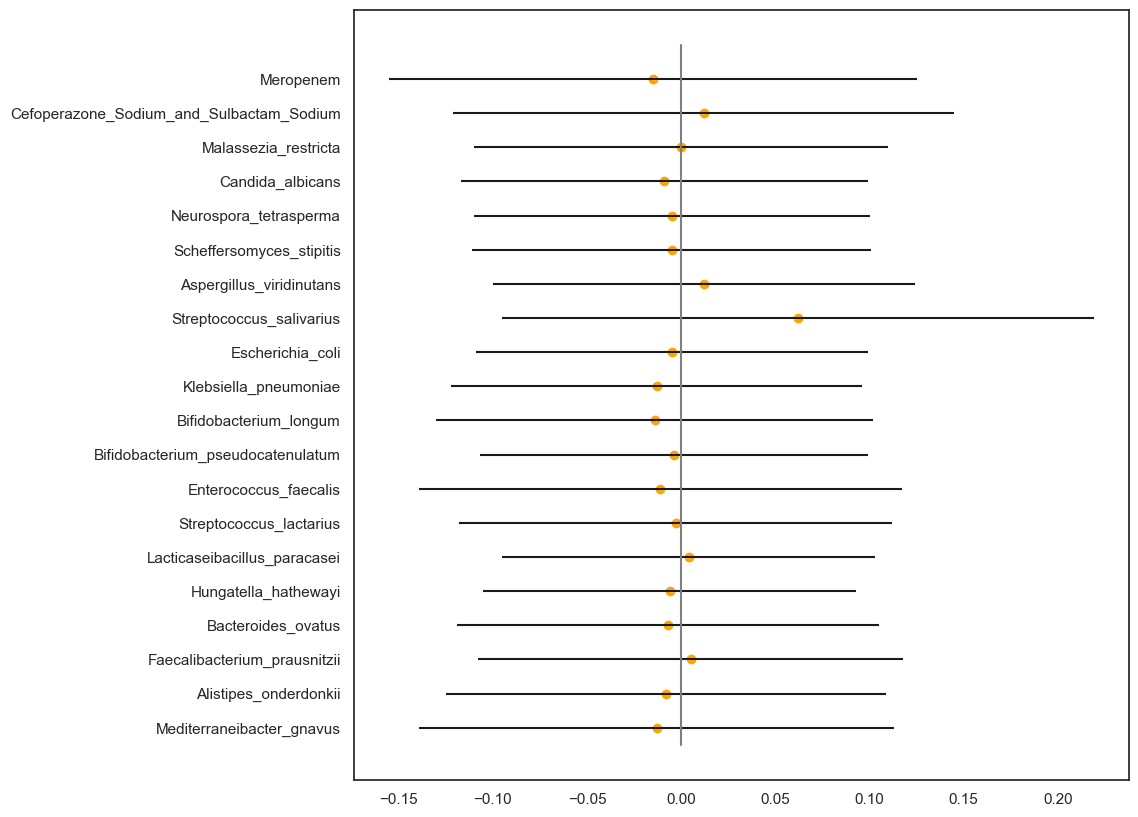

(213, 2)


The version of PyMC you are using is very outdated.

Please upgrade to the latest version of PyMC https://www.pymc.io/projects/docs/en/stable/installation.html

Also notice that PyMC3 has been renamed to PyMC.
D:\environment\envs\pymc3\lib\site-packages\deprecat\classic.py:232: FutureWarning: In v4.0, pm.sample will return an `arviz.InferenceData` object instead of a `MultiTrace` by default. You can pass return_inferencedata=True or return_inferencedata=False to be safe and silence this warning.
  return wrapped_(*args_, **kwargs_)
Sequential sampling (2 chains in 1 job)
CompoundStep
>BinaryGibbsMetropolis: [xi_taxa, xi_drugs]
>NUTS: [intercp, my_sigma, beta_drugs, tau_drugs, beta_taxa, tau_taxa]


Sampling 2 chains for 2_500 tune and 10_000 draw iterations (5_000 + 20_000 draws total) took 1031 seconds.
There were 377 divergences after tuning. Increase `target_accept` or reparameterize.
The acceptance probability does not match the target. It is 0.5280310033427871, but should be close to 0.8. Try to increase the number of tuning steps.
There were 1151 divergences after tuning. Increase `target_accept` or reparameterize.
The estimated number of effective samples is smaller than 200 for some parameters.
Got error No model on context stack. trying to find log_likelihood in translation.
D:\environment\envs\pymc3\lib\site-packages\arviz\data\io_pymc3_3x.py:98: FutureWarning: Using `from_pymc3` without the model will be deprecated in a future release. Not using the model will return less accurate and less useful results. Make sure you use the model argument or call from_pymc3 within a model context.
  warnings.warn(


Streptococcus_salivarius


<Figure size 640x480 with 0 Axes>

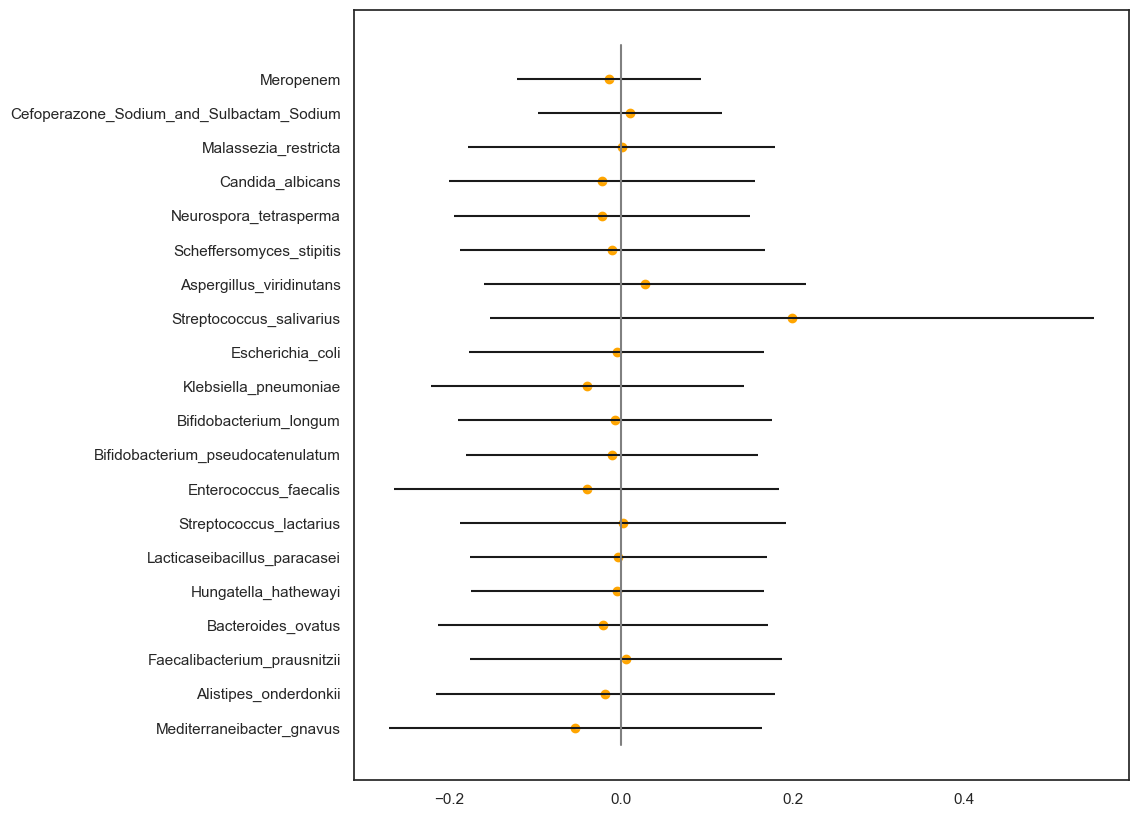

(97, 3)


The version of PyMC you are using is very outdated.

Please upgrade to the latest version of PyMC https://www.pymc.io/projects/docs/en/stable/installation.html

Also notice that PyMC3 has been renamed to PyMC.
D:\environment\envs\pymc3\lib\site-packages\deprecat\classic.py:232: FutureWarning: In v4.0, pm.sample will return an `arviz.InferenceData` object instead of a `MultiTrace` by default. You can pass return_inferencedata=True or return_inferencedata=False to be safe and silence this warning.
  return wrapped_(*args_, **kwargs_)
Sequential sampling (2 chains in 1 job)
CompoundStep
>BinaryGibbsMetropolis: [xi_taxa, xi_drugs]
>NUTS: [intercp, my_sigma, beta_drugs, tau_drugs, beta_taxa, tau_taxa]


Sampling 2 chains for 2_500 tune and 10_000 draw iterations (5_000 + 20_000 draws total) took 871 seconds.
There were 77 divergences after tuning. Increase `target_accept` or reparameterize.
There were 202 divergences after tuning. Increase `target_accept` or reparameterize.
The acceptance probability does not match the target. It is 0.7113166502878487, but should be close to 0.8. Try to increase the number of tuning steps.
The number of effective samples is smaller than 10% for some parameters.
Got error No model on context stack. trying to find log_likelihood in translation.
D:\environment\envs\pymc3\lib\site-packages\arviz\data\io_pymc3_3x.py:98: FutureWarning: Using `from_pymc3` without the model will be deprecated in a future release. Not using the model will return less accurate and less useful results. Make sure you use the model argument or call from_pymc3 within a model context.
  warnings.warn(


Aspergillus_viridinutans


<Figure size 640x480 with 0 Axes>

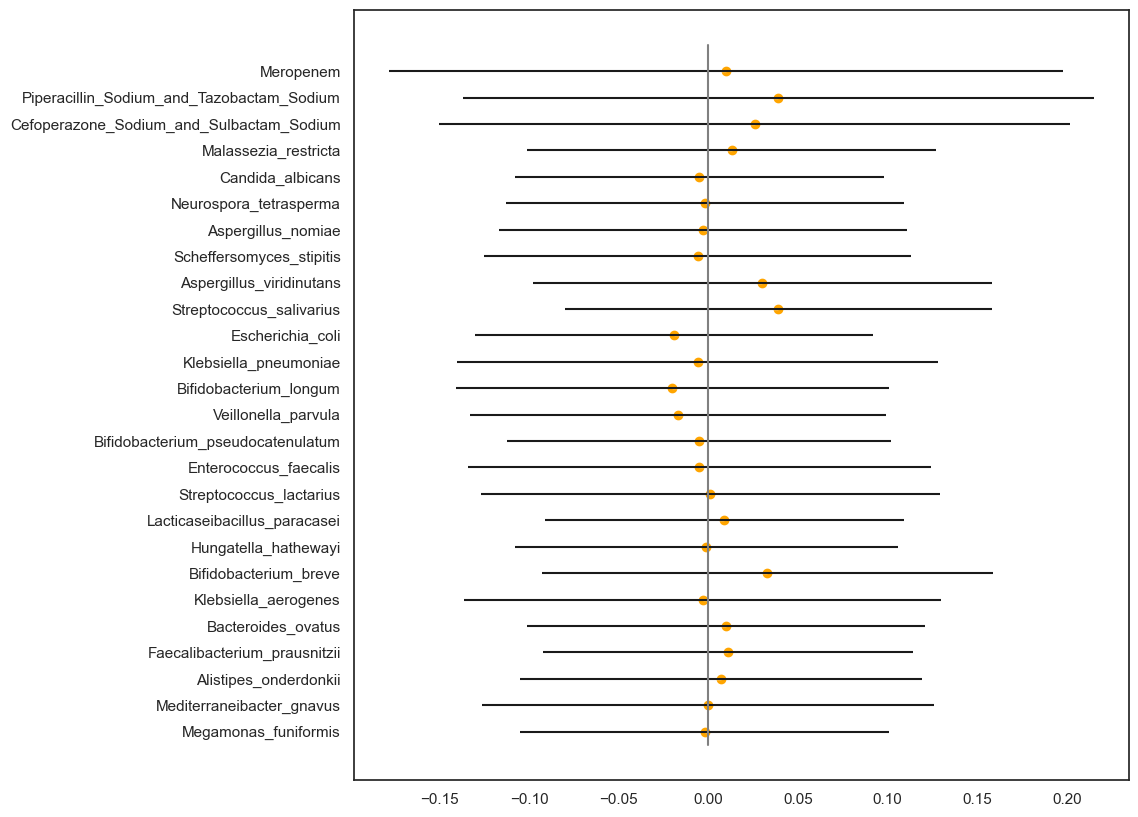

(84, 3)


The version of PyMC you are using is very outdated.

Please upgrade to the latest version of PyMC https://www.pymc.io/projects/docs/en/stable/installation.html

Also notice that PyMC3 has been renamed to PyMC.
D:\environment\envs\pymc3\lib\site-packages\deprecat\classic.py:232: FutureWarning: In v4.0, pm.sample will return an `arviz.InferenceData` object instead of a `MultiTrace` by default. You can pass return_inferencedata=True or return_inferencedata=False to be safe and silence this warning.
  return wrapped_(*args_, **kwargs_)
Sequential sampling (2 chains in 1 job)
CompoundStep
>BinaryGibbsMetropolis: [xi_taxa, xi_drugs]
>NUTS: [intercp, my_sigma, beta_drugs, tau_drugs, beta_taxa, tau_taxa]


Sampling 2 chains for 2_500 tune and 10_000 draw iterations (5_000 + 20_000 draws total) took 953 seconds.
There were 216 divergences after tuning. Increase `target_accept` or reparameterize.
There were 244 divergences after tuning. Increase `target_accept` or reparameterize.
The number of effective samples is smaller than 10% for some parameters.
Got error No model on context stack. trying to find log_likelihood in translation.
D:\environment\envs\pymc3\lib\site-packages\arviz\data\io_pymc3_3x.py:98: FutureWarning: Using `from_pymc3` without the model will be deprecated in a future release. Not using the model will return less accurate and less useful results. Make sure you use the model argument or call from_pymc3 within a model context.
  warnings.warn(


Scheffersomyces_stipitis


<Figure size 640x480 with 0 Axes>

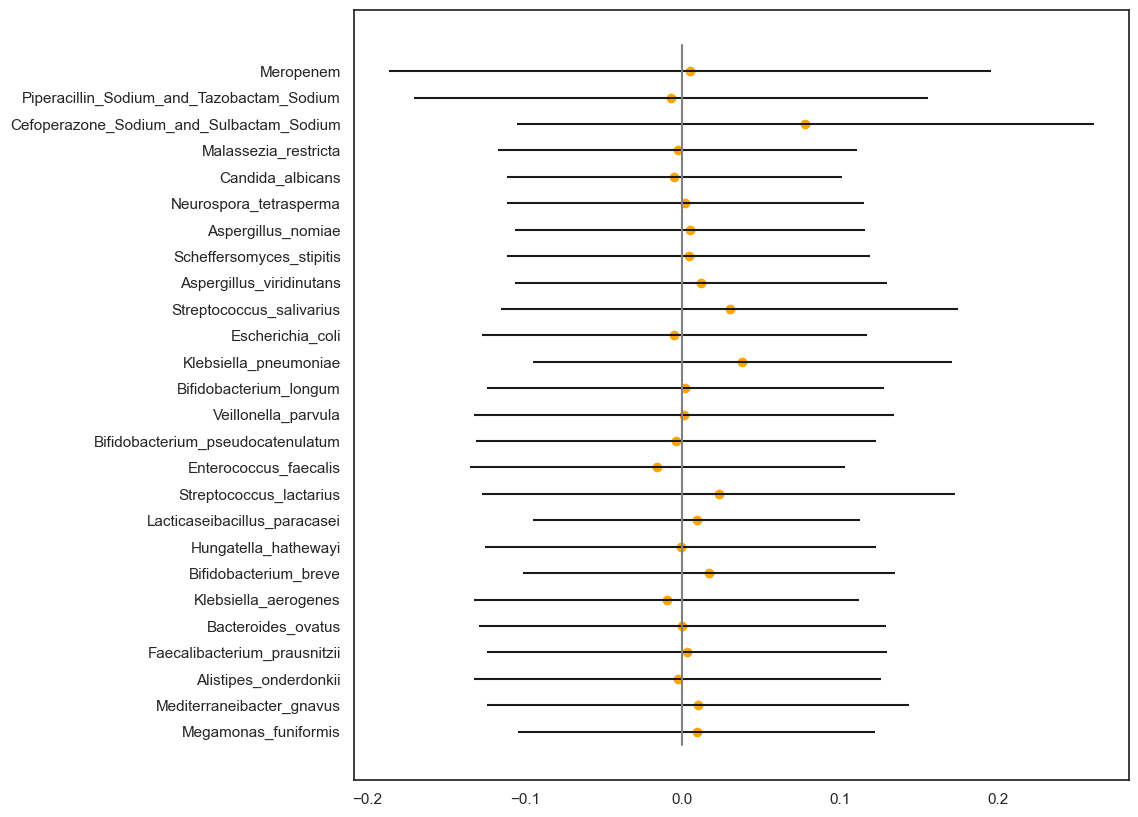

(187, 3)


The version of PyMC you are using is very outdated.

Please upgrade to the latest version of PyMC https://www.pymc.io/projects/docs/en/stable/installation.html

Also notice that PyMC3 has been renamed to PyMC.
D:\environment\envs\pymc3\lib\site-packages\deprecat\classic.py:232: FutureWarning: In v4.0, pm.sample will return an `arviz.InferenceData` object instead of a `MultiTrace` by default. You can pass return_inferencedata=True or return_inferencedata=False to be safe and silence this warning.
  return wrapped_(*args_, **kwargs_)
Sequential sampling (2 chains in 1 job)
CompoundStep
>BinaryGibbsMetropolis: [xi_taxa, xi_drugs]
>NUTS: [intercp, my_sigma, beta_drugs, tau_drugs, beta_taxa, tau_taxa]


Sampling 2 chains for 2_500 tune and 10_000 draw iterations (5_000 + 20_000 draws total) took 827 seconds.
There were 75 divergences after tuning. Increase `target_accept` or reparameterize.
There were 224 divergences after tuning. Increase `target_accept` or reparameterize.
The acceptance probability does not match the target. It is 0.6873115377093154, but should be close to 0.8. Try to increase the number of tuning steps.
The number of effective samples is smaller than 10% for some parameters.
Got error No model on context stack. trying to find log_likelihood in translation.
D:\environment\envs\pymc3\lib\site-packages\arviz\data\io_pymc3_3x.py:98: FutureWarning: Using `from_pymc3` without the model will be deprecated in a future release. Not using the model will return less accurate and less useful results. Make sure you use the model argument or call from_pymc3 within a model context.
  warnings.warn(


Aspergillus_nomiae


<Figure size 640x480 with 0 Axes>

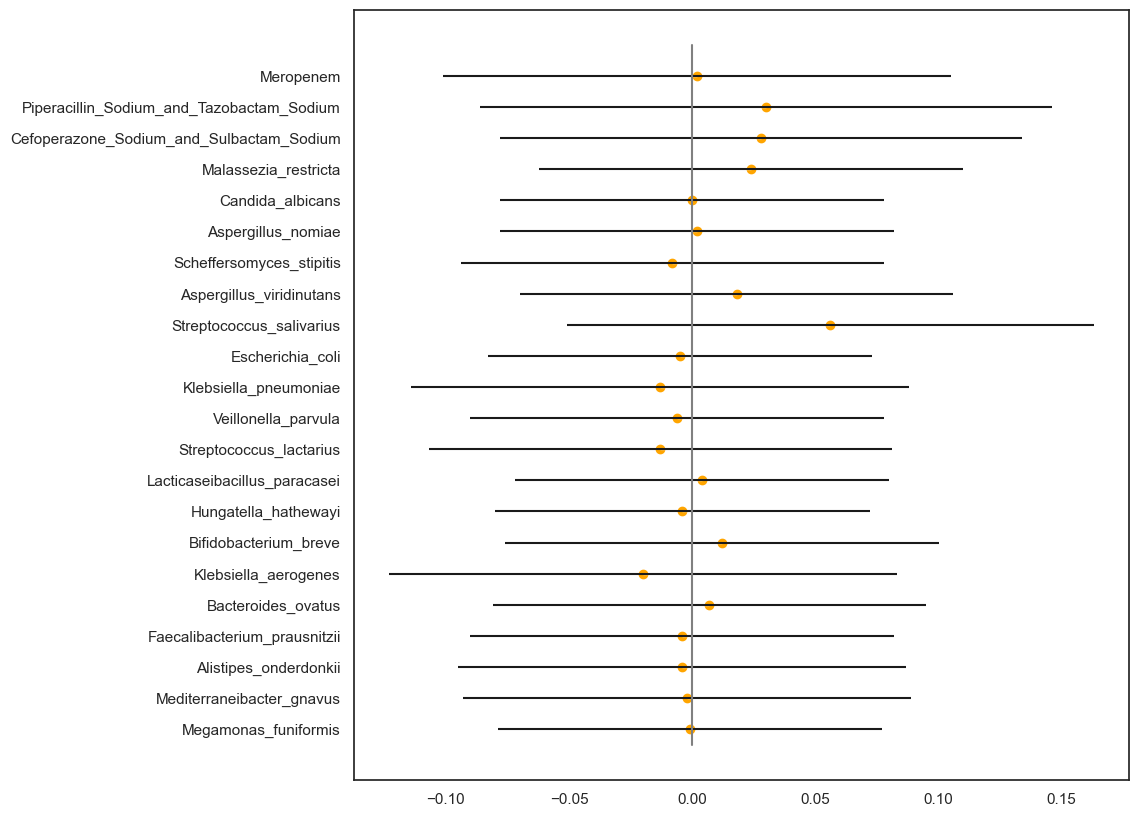

(213, 2)


The version of PyMC you are using is very outdated.

Please upgrade to the latest version of PyMC https://www.pymc.io/projects/docs/en/stable/installation.html

Also notice that PyMC3 has been renamed to PyMC.
D:\environment\envs\pymc3\lib\site-packages\deprecat\classic.py:232: FutureWarning: In v4.0, pm.sample will return an `arviz.InferenceData` object instead of a `MultiTrace` by default. You can pass return_inferencedata=True or return_inferencedata=False to be safe and silence this warning.
  return wrapped_(*args_, **kwargs_)
Sequential sampling (2 chains in 1 job)
CompoundStep
>BinaryGibbsMetropolis: [xi_taxa, xi_drugs]
>NUTS: [intercp, my_sigma, beta_drugs, tau_drugs, beta_taxa, tau_taxa]


Sampling 2 chains for 2_500 tune and 10_000 draw iterations (5_000 + 20_000 draws total) took 782 seconds.
There were 108 divergences after tuning. Increase `target_accept` or reparameterize.
There were 415 divergences after tuning. Increase `target_accept` or reparameterize.
The number of effective samples is smaller than 10% for some parameters.
Got error No model on context stack. trying to find log_likelihood in translation.
D:\environment\envs\pymc3\lib\site-packages\arviz\data\io_pymc3_3x.py:98: FutureWarning: Using `from_pymc3` without the model will be deprecated in a future release. Not using the model will return less accurate and less useful results. Make sure you use the model argument or call from_pymc3 within a model context.
  warnings.warn(


Neurospora_tetrasperma


<Figure size 640x480 with 0 Axes>

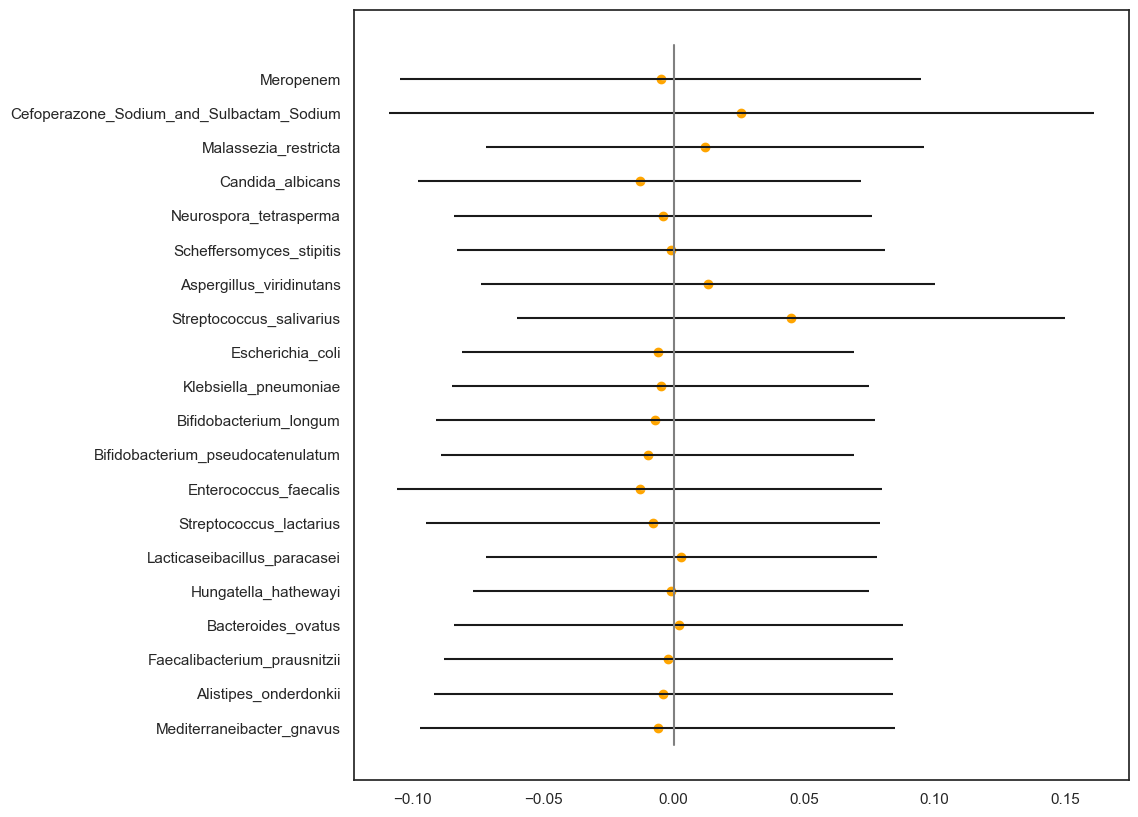

(164, 3)


The version of PyMC you are using is very outdated.

Please upgrade to the latest version of PyMC https://www.pymc.io/projects/docs/en/stable/installation.html

Also notice that PyMC3 has been renamed to PyMC.
D:\environment\envs\pymc3\lib\site-packages\deprecat\classic.py:232: FutureWarning: In v4.0, pm.sample will return an `arviz.InferenceData` object instead of a `MultiTrace` by default. You can pass return_inferencedata=True or return_inferencedata=False to be safe and silence this warning.
  return wrapped_(*args_, **kwargs_)
Sequential sampling (2 chains in 1 job)
CompoundStep
>BinaryGibbsMetropolis: [xi_taxa, xi_drugs]
>NUTS: [intercp, my_sigma, beta_drugs, tau_drugs, beta_taxa, tau_taxa]


Sampling 2 chains for 2_500 tune and 10_000 draw iterations (5_000 + 20_000 draws total) took 935 seconds.
There were 116 divergences after tuning. Increase `target_accept` or reparameterize.
There were 304 divergences after tuning. Increase `target_accept` or reparameterize.
The acceptance probability does not match the target. It is 0.6434221466615648, but should be close to 0.8. Try to increase the number of tuning steps.
The estimated number of effective samples is smaller than 200 for some parameters.
Got error No model on context stack. trying to find log_likelihood in translation.
D:\environment\envs\pymc3\lib\site-packages\arviz\data\io_pymc3_3x.py:98: FutureWarning: Using `from_pymc3` without the model will be deprecated in a future release. Not using the model will return less accurate and less useful results. Make sure you use the model argument or call from_pymc3 within a model context.
  warnings.warn(


Candida_albicans


<Figure size 640x480 with 0 Axes>

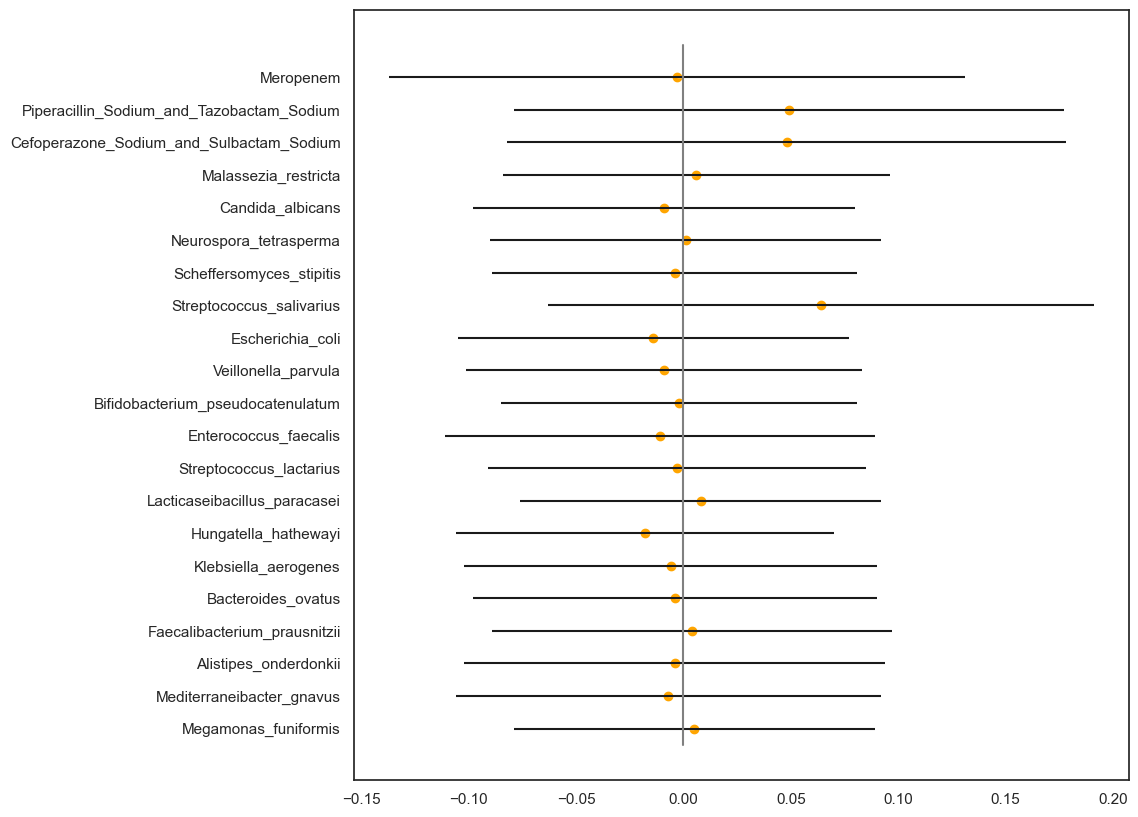

(151, 3)


The version of PyMC you are using is very outdated.

Please upgrade to the latest version of PyMC https://www.pymc.io/projects/docs/en/stable/installation.html

Also notice that PyMC3 has been renamed to PyMC.
D:\environment\envs\pymc3\lib\site-packages\deprecat\classic.py:232: FutureWarning: In v4.0, pm.sample will return an `arviz.InferenceData` object instead of a `MultiTrace` by default. You can pass return_inferencedata=True or return_inferencedata=False to be safe and silence this warning.
  return wrapped_(*args_, **kwargs_)
Sequential sampling (2 chains in 1 job)
CompoundStep
>BinaryGibbsMetropolis: [xi_taxa, xi_drugs]
>NUTS: [intercp, my_sigma, beta_drugs, tau_drugs, beta_taxa, tau_taxa]


Sampling 2 chains for 2_500 tune and 10_000 draw iterations (5_000 + 20_000 draws total) took 869 seconds.
There were 51 divergences after tuning. Increase `target_accept` or reparameterize.
The acceptance probability does not match the target. It is 0.7197255961019094, but should be close to 0.8. Try to increase the number of tuning steps.
There were 116 divergences after tuning. Increase `target_accept` or reparameterize.
The acceptance probability does not match the target. It is 0.6610941811717075, but should be close to 0.8. Try to increase the number of tuning steps.
The number of effective samples is smaller than 10% for some parameters.
Got error No model on context stack. trying to find log_likelihood in translation.
D:\environment\envs\pymc3\lib\site-packages\arviz\data\io_pymc3_3x.py:98: FutureWarning: Using `from_pymc3` without the model will be deprecated in a future release. Not using the model will return less accurate and less useful results. Make sure you use the model

Malassezia_restricta


<Figure size 640x480 with 0 Axes>

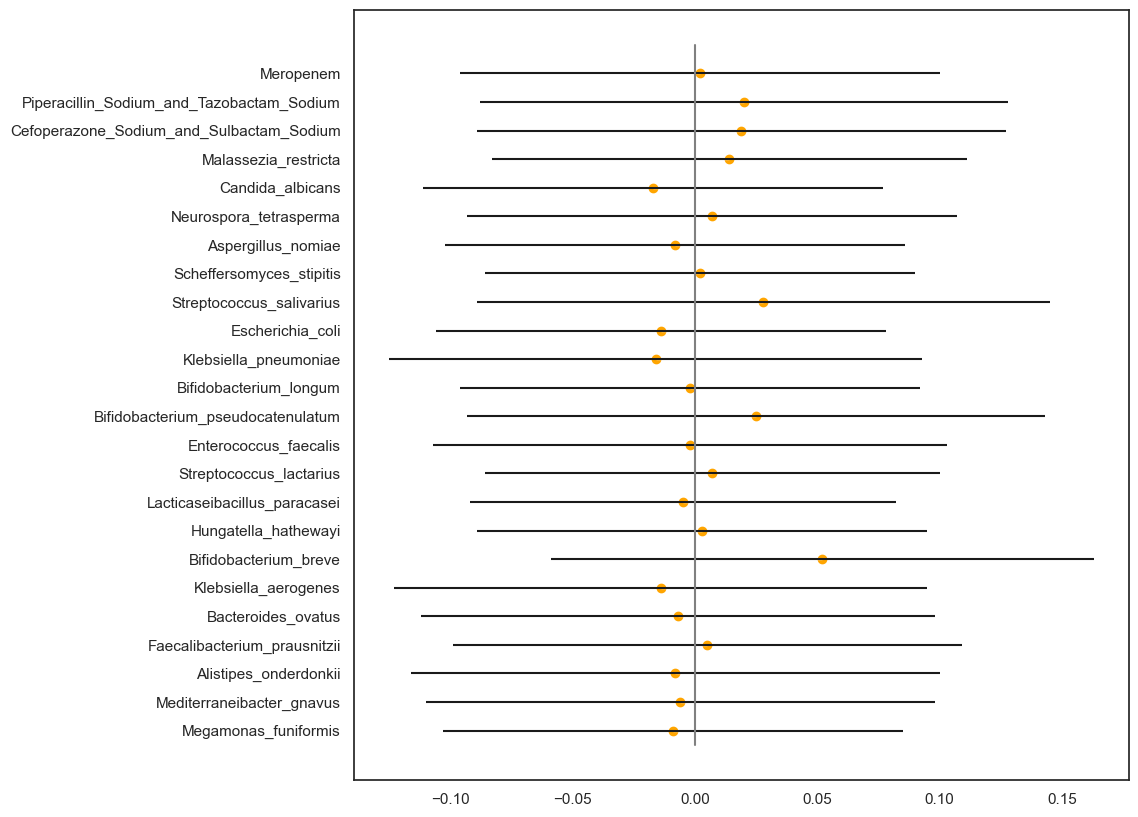

<Figure size 640x480 with 0 Axes>

In [12]:
save_all_X = all_X.copy()
save_all_Y = all_Y.copy()

store_all_interactions = pd.DataFrame()
store_intercepts = pd.DataFrame()

tmp = save_all_X.copy()
tmp[tmp>0]=1

for focal_species in all_Y.columns:
    
    my_all_X = save_all_X.copy()
    my_all_Y = save_all_Y.copy()

    # Drop samples without focal species        
    my_all_X = my_all_X.drop(my_all_X.loc[my_all_X[focal_species] ==0,:].index)
    my_all_Y = my_all_Y.loc[my_all_X.index,:].copy()
    
    # 创建my_all_Y的副本
    my_all_Y_copy = my_all_Y.copy()


    
    if len(my_all_Y) > 10:

        # Standardize all X variables
        tmp = StandardScaler().fit_transform(my_all_X)
        my_all_X = pd.DataFrame(tmp, index = my_all_X.index, columns = my_all_X.columns)
        
        
        model = pm.Model()
 #       X_taxa = my_all_X.copy()[my_all_Y.columns]
        X_taxa = my_all_X.copy()[my_all_Y_copy.columns]
        X_drugs = my_all_X.copy().drop(X_taxa.columns, axis=1)
               
        X_taxa = X_taxa.drop(X_taxa.loc[:,X_taxa.sum()==0].columns,axis=1)
        X_drugs = X_drugs.drop(X_drugs.loc[:,X_drugs.sum()==0].columns,axis=1)

        y = my_all_Y[focal_species].copy()

        
        # Set up priors for model
        
        Sigma_taxa = np.matmul(X_taxa.T.values, X_taxa.values) * 0.5
        Sigma_taxa += np.diag(np.diag(Sigma_taxa))
        Sigma_taxa = np.linalg.inv(Sigma_taxa)
        #Sigma_taxa = np.identity(len(Sigma_taxa)) # alternatively use identity matrix (results same)
        
        Sigma_drugs = np.matmul(X_drugs.T.values, X_drugs.values) * 0.5
        Sigma_drugs += np.diag(np.diag(Sigma_drugs))
        Sigma_drugs = np.linalg.inv(Sigma_drugs)
        #Sigma_drugs = np.identity(len(Sigma_drugs)) # alternatively use identity matrix (results same)
        
        # For calculating growth rate initialisation
        X_growth = my_all_X.copy()
        X_growth = sm.add_constant(X_growth)
        Y = my_all_Y[focal_species].copy()
        r_model = sm.OLS(Y,X_growth)
    
        results = r_model.fit()
        init_r = results.params['const']
        if init_r < 0:
            init_r = 0
            
        init_r_std= np.std(results.params) # inflate initial prior for intercept
    
        
        with pm.Model() as model:
            
            xi_taxa = pm.Bernoulli('xi_taxa', .5, shape=X_taxa.shape[1])
            tau_taxa = pm.HalfCauchy('tau_taxa', 1)
            beta_taxa = pm.MvNormal('beta_taxa', 0, tau_taxa * Sigma_taxa, shape=X_taxa.shape[1])
            mean_taxa = pm.math.dot(X_taxa, xi_taxa * beta_taxa)
            # 检查 X_drugs 的形状
            print(X_drugs.shape)

            # 在使用之前确保 X_drugs 具有有效的形状
            if X_drugs.shape[1] <= 0:
                raise ValueError("X_drugs 的形状无效。请检查数据或计算。")
 

            xi_drugs = pm.Bernoulli('xi_drugs', .5, shape=X_drugs.shape[1])
            tau_drugs = pm.HalfCauchy('tau_drugs', 1)
            beta_drugs = pm.MvNormal('beta_drugs', 0, tau_drugs * Sigma_drugs, shape=X_drugs.shape[1])
            mean_drugs = pm.math.dot(X_drugs, xi_drugs * beta_drugs)
            
            my_sigma = pm.HalfNormal('my_sigma', 10) 

            
            intercp = pm.Bound(pm.Normal, lower=0.0)('intercp', mu=1.0, tau=(init_r_std**2)*1e2)
            
            my_var = pm.Normal('my_var', mean_drugs + mean_taxa + intercp, my_sigma, observed=y)

            lasso_normal_trace_s = pm.sample(draws =10000,tune=2500, init='adapt_diag', cores=-1)



        my_summary = pm.summary(lasso_normal_trace_s)
        
        store_intercepts.loc[focal_species, 'ic'] = my_summary.loc['intercp','mean']
        
        new_summary = pd.DataFrame()
        for ix, val in enumerate(X_taxa.columns):
            #cur_index = 'beta_taxa__' + str(ix)
            cur_index = 'beta_taxa[' + str(ix) + ']'
            cur_mean = my_summary.loc[cur_index, 'mean']
            cur_sd = my_summary.loc[cur_index, 'sd']
            try:
                rename_val = val + '_' + otu_table.loc[val, 'family']
            except:
                rename_val = val
            new_summary.loc[rename_val, 'cur_mean'] = cur_mean
            new_summary.loc[rename_val, 'cur_sd'] = cur_sd
            store_all_interactions.loc[focal_species, val] = cur_mean



        for ix, val in enumerate(X_drugs.columns):
            #cur_index = 'beta_drugs__' + str(ix)
            cur_index = 'beta_drugs[' + str(ix) + ']'
            cur_mean = my_summary.loc[cur_index, 'mean']
            cur_sd = my_summary.loc[cur_index, 'sd']
            try:
                rename_val = val + '_' + otu_table.loc[val, 'family']
            except:
                rename_val = val
            new_summary.loc[rename_val, 'cur_mean'] = cur_mean
            new_summary.loc[rename_val, 'cur_sd'] = cur_sd
            store_all_interactions.loc[focal_species, val] = cur_mean


        try:
            print(focal_species, otu_table.loc[focal_species, 'family'])
        except:
            print(focal_species)
        sns.set_style('white')
        plt.figure(figsize=(10,10))

        plt.scatter(x = new_summary.cur_mean, y = new_summary.index, c='orange')
        plt.barh(y = new_summary.index,
                width = new_summary.cur_mean,
                height=0.0,
                xerr= new_summary.cur_sd)
        plt.plot([0,0],[-0.5,len(new_summary)+0.0],'gray')
        plt.savefig(f'E:/projects/肝移植/fig3/glv/figure/wo/species/{focal_species}.pdf', format='pdf')
        plt.show()
        plt.clf()
    
   # break

In [117]:
#st.write_file('./all_interactions.txt', store_all_interactions)

In [13]:
store_all_interactions.to_csv('E:/projects/肝移植/fig3/glv/figure/wo/species/all_interactions0215.txt', sep='\t')

In [3]:
store_all_interactions = pd.read_table('E:/projects/肝移植/fig3/glv/figure/wo/species/all_interactions0210.txt',sep='\t',index_col=0)

In [4]:
store_all_interactions

,Megamonas_funiformis,Mediterraneibacter_gnavus,Alistipes_onderdonkii,Faecalibacterium_prausnitzii,Bacteroides_ovatus,Klebsiella_aerogenes,Hungatella_hathewayi,Lacticaseibacillus_paracasei,Streptococcus_lactarius,Enterococcus_faecalis,Scheffersomyces_stipitis,Aspergillus_nomiae,Neurospora_tetrasperma,Cefoperazone_Sodium_and_Sulbactam_Sodium,Piperacillin_Sodium_and_Tazobactam_Sodium,Bifidobacterium_breve,Bifidobacterium_pseudocatenulatum,Meropenem,Aspergillus_viridinutans
Megamonas_funiformis,-0.006,-0.003,-0.008,0.003,-0.001,-0.012,-0.009,0.006,0.001,0.003,0.001,0.011,0.001,0.027,0.023,NaN,NaN,NaN,NaN
Mediterraneibacter_gnavus,0.001,-0.003,-0.003,0.002,0.003,NaN,-0.011,0.007,NaN,-0.000,0.005,-0.001,0.015,0.004,0.015,0.002,0.002,-0.010,NaN
Alistipes_onderdonkii,0.005,0.009,-0.015,0.013,-0.014,-0.001,-0.040,0.019,0.003,-0.006,0.007,0.008,0.027,0.015,0.013,0.004,0.120,0.001,0.033
Faecalibacterium_prausnitzii,NaN,-0.003,-0.001,0.003,-0.000,NaN,-0.006,0.012,0.000,-0.001,-0.001,NaN,0.003,0.017,NaN,NaN,-0.000,-0.007,0.011
Bacteroides_ovatus,NaN,-0.003,-0.004,0.003,-0.002,-0.004,NaN,-0.003,0.006,-0.000,0.003,0.003,0.000,0.012,0.014,0.002,0.002,-0.000,0.001
Klebsiella_aerogenes,NaN,-0.004,-0.004,-0.002,0.002,NaN,-0.005,0.004,0.003,-0.005,-0.002,NaN,-0.002,0.008,NaN,NaN,-0.001,-0.009,0.007
Bifidobacterium_breve,NaN,0.000,-0.002,0.010,0.001,NaN,-0.006,0.006,0.003,-0.001,-0.004,NaN,-0.014,0.006,NaN,NaN,0.001,-0.004,0.025
Hungatella_hathewayi,0.002,-0.003,-0.005,-0.001,0.002,-0.003,-0.004,0.006,0.001,0.001,0.003,0.004,-0.004,0.011,0.017,-0.002,NaN,-0.000,0.008
Lacticaseibacillus_paracasei,-0.009,-0.000,-0.010,0.007,-0.006,0.008,-0.013,0.010,0.001,-0.005,NaN,NaN,0.002,0.021,0.016,0.004,-0.006,-0.004,0.008
Streptococcus_lactarius,NaN,-0.004,-0.006,0.000,-0.005,NaN,-0.005,-0.000,0.006,-0.002,-0.002,NaN,-0.006,0.010,NaN,NaN,0.002,-0.001,0.013


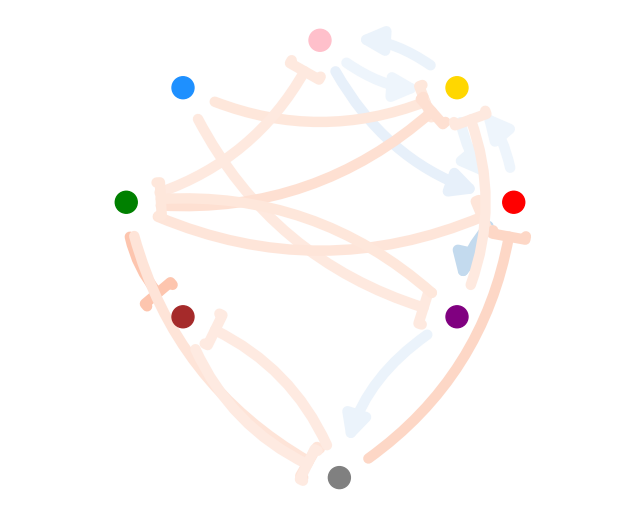

In [27]:
### Plot positive edges ###
#G=nx.from_numpy_matrix(np.array(cm_pos),
#                       create_using=nx.MultiDiGraph())
f, ax = plt.subplots(1,figsize=(8, 6.5))
my_list = ['Bifidobacterium_breve',
            'Lacticaseibacillus_paracasei',
    'Faecalibacterium_prausnitzii',
           'Megamonas_funiformis',
        'Enterococcus_faecalis',
           'Streptococcus_lactarius','Neurospora_tetrasperma']
### Split interactions into positive and negative for plotting ###
cur_matrix = store_all_interactions.copy()
cur_matrix[abs(cur_matrix) <0.008]=0 # filter out very weak interactions
cur_matrix = cur_matrix.loc[my_list, my_list].T
cm_pos = cur_matrix.copy()
cm_pos[cm_pos<0]=0
cm_neg = cur_matrix.copy()
cm_neg[cm_neg>0]=0
import networkx as nx
G=nx.from_numpy_array(np.array(cm_pos),
                       create_using=nx.MultiDiGraph())

pos = nx.layout.circular_layout(G)
pos[6] = (pos[6][0] + 0.1, pos[6][1]-0.7)

M = G.number_of_edges()
edge_colors = np.zeros(M)
for ix, e in enumerate(G.edges(data=True)):
    edge_colors[ix] = abs(e[2]['weight'])

for cix, cn in enumerate(G.edges()):
    e = FancyArrowPatch(pos[cn[0]],
                        pos[cn[1]],
                            arrowstyle='-|>',
                            connectionstyle='arc3,rad=0.25',
                            mutation_scale=35.0,
                            lw=7.5,
                            color=cm.Blues(edge_colors[cix]*5),
                            shrinkA=25,
                            shrinkB=25)
    ax.add_patch(e)

    
### Plot negative edges ###
#G=nx.from_numpy_matrix(np.array(cm_neg),
#                      create_using=nx.MultiDiGraph())
G=nx.from_numpy_array(np.array(cm_neg),
                       create_using=nx.MultiDiGraph())

M = G.number_of_edges()
edge_colors = np.zeros(M)
for ix, e in enumerate(G.edges(data=True)):
    edge_colors[ix] = abs(e[2]['weight'])

for cix, cn in enumerate(G.edges()):
    e = FancyArrowPatch(pos[cn[0]],
                        pos[cn[1]],
                            arrowstyle='-[',
                            connectionstyle='arc3,rad=0.25',
                            mutation_scale=12.0,
                            lw=7.5,
                            color=cm.Reds(edge_colors[cix]*8),
                            shrinkA=25,
                            shrinkB=25)
    ax.add_patch(e)


### Plot nodes ###
node_colors = ['red', 'gold','pink','dodgerblue', 'green', 'brown','grey','purple']
nx.draw_networkx_nodes(G,pos,nodelist=range(8),node_shape='o', node_size=250, node_color= node_colors[0:8])
#nx.draw_networkx_nodes(G,pos,nodelist=[4],node_shape='o', node_size=250, node_color=['brown'])
    
    
### Fix axis ###
ax.set_xlim([-1.1,1.1])
ax.set_ylim([-1.1,1.1])
plt.axis('off')
plot_margin = 0.5
x0, x1, y0, y1 = plt.axis()
plt.axis((x0 - plot_margin,
          x1 + plot_margin,
          y0 -plot_margin-0.3,
          y1 + 0.09))

#plt.savefig("E:/projects/肝移植/fig3/glv/new/wo.s.0212.pdf", format="pdf", bbox_inches='tight')  # 导出为PDF
plt.show()

#print("图形已保存为output_plot.pdf")

In [10]:
# Get antimicrobial interactions
abx_matrix = store_all_interactions.copy()
abx_matrix = abx_matrix.drop(my_bacteria,axis=1)
#abx_matrix = abx_matrix.drop(my_fungi,axis = 1).fillna(0)
#abx_matrix[abs(abx_matrix) < 0.001] = 0

NameError: name 'my_bacteria' is not defined

In [11]:
## Split up antimicrobial matrix
# bacteria / antibiotics
#bac_abx = abx_matrix.loc[my_bacteria,antibacterials].copy().dropna(1)
bac_abx = abx_matrix.copy().dropna()
store_abx_tmp = pd.DataFrame()
for col in bac_abx.columns:
    tmp = bac_abx.loc[:,col]
    #store_abx_tmp = pd.concat([store_abx_tmp, pd.DataFrame(tmp[tmp! = 0].get_values())])
    store_abx_tmp = pd.concat([store_abx_tmp, pd.DataFrame(tmp[tmp!=0].to_numpy())])
store_abx_tmp = store_abx_tmp.reset_index().drop(['index'], axis = 1)

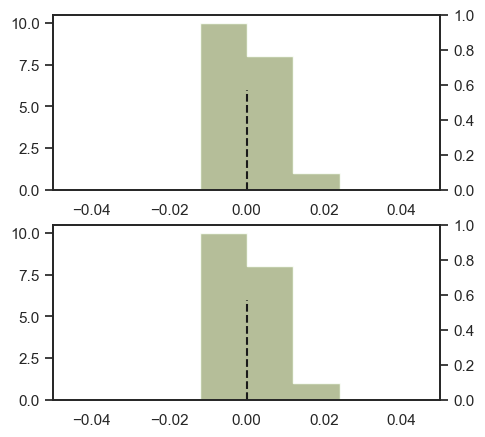

In [152]:
# bacteria / antifungals
#bac_anf = abx_matrix.loc[my_bacteria,antifungals].copy().dropna(1)
bac_anf = abx_matrix.copy().dropna()
store_anf_tmp = pd.DataFrame()
for col in bac_anf.columns:
    tmp = bac_anf.loc[:,col]
    #store_anf_tmp = pd.concat([store_anf_tmp, pd.DataFrame(tmp[tmp! = 0].get_values())])
    store_anf_tmp = pd.concat([store_anf_tmp, pd.DataFrame(tmp[tmp!=0].to_numpy())])
store_anf_tmp = store_anf_tmp.reset_index().drop(['index'],axis = 1)

# fungi / antibiotics
#fun_abx = abx_matrix.loc[my_fungi,antibacterials].copy().drop(['Aspergillus'])
fun_abx = abx_matrix.copy()
fun_abx  = fun_abx.dropna()
store_abx_tmp_fun = pd.DataFrame()
for col in fun_abx.columns:
    tmp = fun_abx.loc[:,col]
    #store_abx_tmp_fun = pd.concat([store_abx_tmp_fun, pd.DataFrame(tmp[tmp! = 0].get_values())])
    store_abx_tmp_fun = pd.concat([store_abx_tmp_fun, pd.DataFrame(tmp[tmp!=0].to_numpy())])
store_abx_tmp_fun = store_abx_tmp_fun.reset_index().drop(['index'],axis = 1)

# fungi / antifungals
#fun_anf = abx_matrix.loc[my_fungi,antifungals].copy().drop(['Aspergillus'])
fun_anf = abx_matrix.copy()
fun_anf  = fun_anf.dropna()
store_anf_tmp_fun = pd.DataFrame()
for col in fun_anf.columns:
    tmp = fun_anf.loc[:,col]
    #store_anf_tmp_fun = pd.concat([store_anf_tmp_fun, pd.DataFrame(tmp[tmp! = 0].get_values())])
    store_anf_tmp_fun = pd.concat([store_anf_tmp_fun, pd.DataFrame(tmp[tmp!=0].to_numpy())])
store_anf_tmp_fun = store_anf_tmp_fun.reset_index().drop(['index'],axis = 1)


# Plot separate histograms
fig, ax = plt.subplots(2,1, figsize = (5,5))

thresh_val = 0.05
store_abx_tmp[store_abx_tmp < -thresh_val] = -thresh_val
store_abx_tmp[store_abx_tmp > thresh_val] = thresh_val

store_anf_tmp[store_anf_tmp < -thresh_val] = -thresh_val
store_anf_tmp[store_anf_tmp > thresh_val] = thresh_val

store_abx_tmp_fun[store_abx_tmp_fun < -thresh_val] = -thresh_val
store_abx_tmp_fun[store_abx_tmp_fun > thresh_val] = thresh_val

store_anf_tmp_fun[store_anf_tmp_fun < -thresh_val] = -thresh_val
store_anf_tmp_fun[store_anf_tmp_fun > thresh_val] = thresh_val


my_bins = np.linspace(-3,3,51)*0.1
ax[0].hist(store_abx_tmp.values,
         density = False,
         bins = my_bins,
        histtype = 'stepfilled',
          color = [179/255,129/255,176/255])

ax0_2 = ax[0].twinx() 
ax[0].hist(store_anf_tmp.values,
         density = False,
         bins = my_bins,
        alpha = 0.75,
        histtype = 'stepfilled',
          color = [182/255,212/255,146/255])
ax[0].plot([0,0],[0,6],'k--')
ax[0].set_xlim([-0.05,0.05])

ax[1].hist(store_abx_tmp_fun.values,
         density = False,
         bins = my_bins,
        histtype = 'stepfilled',
          color = [179/255,129/255,176/255])
ax1_2 = ax[1].twinx() 

ax[1].hist(store_anf_tmp_fun.values,
         density = False,
         bins = my_bins,
        alpha = 0.75,
        histtype = 'stepfilled',
        color = [182/255,212/255,146/255])
ax[1].plot([0,0],[0,6],'k--')
ax[1].set_xlim([-0.05,0.05])

plt.show()

In [148]:
# Get just taxa interactions
cur_matrix = store_all_interactions.copy()
cur_matrix = cur_matrix.drop(abx_matrix.columns, axis = 1)
#cur_matrix = cur_matrix.loc[:, cur_matrix.index]
#cur_matrix[abs(cur_matrix) < 0.001] = 0

In [129]:
# Get just taxa interactions
cur_matrix = store_all_interactions.copy()
cur_matrix = cur_matrix.drop(abx_matrix.columns, axis = 1)
#cur_matrix = cur_matrix.loc[:, cur_matrix.index]
#cur_matrix[abs(cur_matrix) <0.001]=0


# Go through and count interactions
count_ints = pd.DataFrame(0, index = ['interaction'], columns = ['-/-', '-/o', '+/-', '+/o', '+/+'])

In [149]:
for ix_sp in cur_matrix.index:
    for col_sp in cur_matrix.columns:
        
        if col_sp != ix_sp:
            ci_focal = cur_matrix.loc[ix_sp, col_sp]
            ci_pair = cur_matrix.loc[col_sp, ix_sp]
            #ci_pair = cur_matrix.loc[ix_sp, col_sp]
            

            if ci_focal > 0:
                if ci_pair > 0:
                    count_ints.loc['interaction', '+/+'] = count_ints.loc['interaction', '+/+'] + 1 # pp
                if ci_pair < 0:
                    count_ints.loc['interaction', '+/-'] = count_ints.loc['interaction', '+/-'] + 1 # pm
                if ci_pair == 0:
                    count_ints.loc['interaction', '+/o'] = count_ints.loc['interaction', '+/o'] + 1 # po

            if ci_focal < 0:
                if ci_pair > 0:
                    count_ints.loc['interaction', '+/-'] = count_ints.loc['interaction', '+/-'] + 1# mp
                if ci_pair < 0:
                    count_ints.loc['interaction', '-/-'] = count_ints.loc['interaction', '-/-'] + 1# mm
                if ci_pair == 0:
                    count_ints.loc['interaction', '-/o'] = count_ints.loc['interaction', '-/o'] + 1# mo

            if ci_focal == 0:
                if ci_pair > 0:
                    count_ints.loc['interaction', '+/o'] = count_ints.loc['interaction', '+/o'] + 1# op
                if ci_pair < 0:
                    count_ints.loc['interaction', '-/o'] = count_ints.loc['interaction', '-/o'] + 1# om 
                
        
# Plot result
fig, ax = plt.subplots(1,1, figsize=(2,5))
colors = ['darkred', 'tomato', 'khaki', 'royalblue', 'darkblue']
count_ints=count_ints/count_ints.sum(1).values[0]
count_ints.plot(kind='bar',
                stacked=True,
                #colors = colors,
                color = colors,
                ax=ax)  
ax.set_ylim(0,1)
ax.legend(bbox_to_anchor=(01.6, 1.00),
          ncol=1, fancybox=True)
plt.show()

KeyError: 'Neurospora'

C:\Users\15837\AppData\Local\Temp\ipykernel_24696\2571230634.py:26: MatplotlibDeprecationWarning: The join function was deprecated in Matplotlib 3.6 and will be removed two minor releases later.
  ax1.get_shared_y_axes().join(ax2)


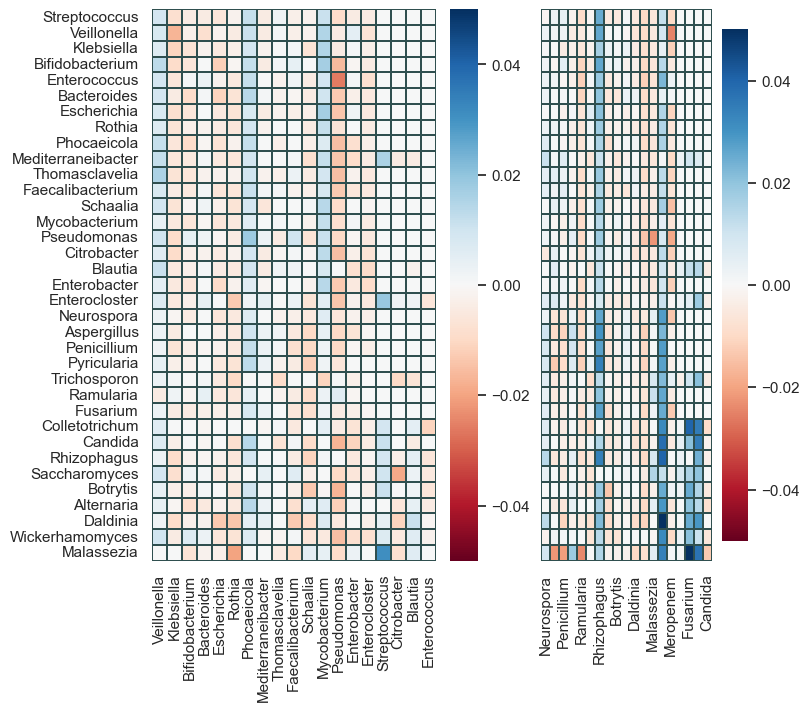

In [153]:
fig = plt.figure(constrained_layout=True, figsize=(8,7))

gs = GridSpec(1, 8, figure=fig)
ax1 = fig.add_subplot(gs[0, 0:5])
ax2 = fig.add_subplot(gs[0, 5:8])#, sharey=ax1)

clusters =  sns.heatmap(cur_matrix.fillna(0),
               cmap='RdBu',
               center=0,
               vmin=-0.05,
               vmax=0.05,
              square=False, ax=ax1,cbar=True,yticklabels=True,linewidths=0.05,
                  linecolor = 'darkslategray',)

clusters =  sns.heatmap(abx_matrix.fillna(0),
               cmap='RdBu',
               center=0,
               vmin=-0.05,
               vmax=0.05,
              square=False,
                ax=ax2,
              cbar=True,
                yticklabels=False,
                       linewidths=0.05,
                  linecolor = 'darkslategray',)
ax1.get_shared_y_axes().join(ax2)
plt.show()

